# SCOPE / REACH Outcome Analysis

Reads all outcomes from `generation.tracked_events` in `pipeline_config.yaml`.
Produces per-outcome AUC and calibration plots, and a single combined efficiency figure.

In [2]:
import pathlib
import yaml

# ── CONFIG ──────────────────────────────────────────────────────────────────
OUTPUT_DIR   = pathlib.Path("scope_reach_output_ucmc_4000")   # directory produced by run_timelines.py
CONFIG_YAML  = pathlib.Path("pipeline_config.yaml") # read tracked_events from here
MAX_PATIENTS = None          # max_patients from pipeline_config.yaml (None = full cohort)
SHUFFLE_SEED = 42           # shuffle_seed from pipeline_config.yaml
MARGINAL     = False         # True: REACH cost = avg_tokens_m2 only (M1 already paid)
                            # False: REACH cost = avg_tokens_m1 + avg_tokens_m2 (standalone)
# ────────────────────────────────────────────────────────────────────────────

with open(CONFIG_YAML) as _f:
    _pipeline_cfg = yaml.safe_load(_f)

OUTCOME_NAMES = _pipeline_cfg["generation"]["tracked_events"]
print(f"Outcomes from config ({len(OUTCOME_NAMES)}):")
for _n in OUTCOME_NAMES:
    print(f"  {_n}")

# Validate all required files exist up front
index_path = OUTPUT_DIR / "patient_index.parquet"
if not index_path.exists():
    raise FileNotFoundError(index_path)
for _name in OUTCOME_NAMES:
    _safe = _name.replace("/", "_").replace(" ", "_")
    _p = OUTPUT_DIR / f"scores_{_safe}.npz"
    if not _p.exists():
        raise FileNotFoundError(_p)

Outcomes from config (11):
  XFR-IN//icu
  RESP//imv
  DSCG//expired
  LAB-RES//sodium_Q0
  LAB-RES//sodium_Q9
  LAB-RES//potassium_Q0
  LAB-RES//potassium_Q9
  LAB-RES//hemoglobin_Q0
  LAB-RES//glucose_serum_Q0
  VTL//heart_rate_Q9
  ASMT//cam_total_positive


In [3]:
import logging
import typing
import warnings

import joblib as jl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.stats import rankdata
from sklearn import metrics as skl_mets
from sklearn.metrics import brier_score_loss
from tqdm.auto import tqdm

plt.rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm"})
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#8B6156", "#b879d185", "#00d192c1", "#d62728"])

COLORS  = {"Monte Carlo": "#8B6156", "SCOPE": "#b879d1cf", "REACH": "#00d192"}
MARKERS = {"Monte Carlo": "o",       "SCOPE": "s",          "REACH": "^"}

c:\Users\lukea\miniconda3\envs\scope_reach\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

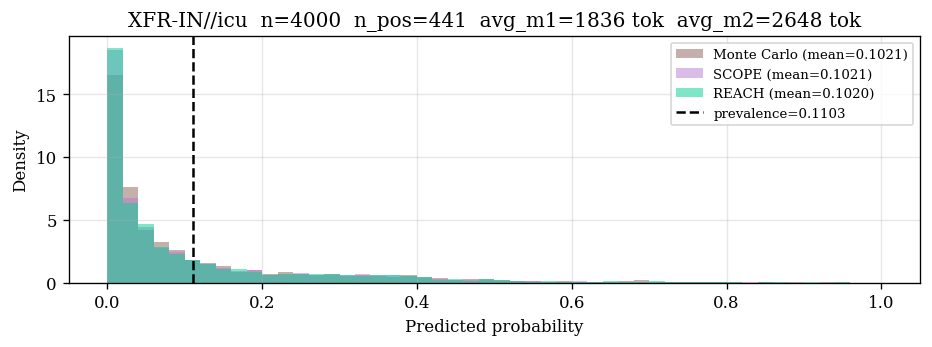

  XFR-IN//icu: n=4000, n_pos=441 (0.110), avg_m1=1836.3 tok, avg_m2=2648.3 tok


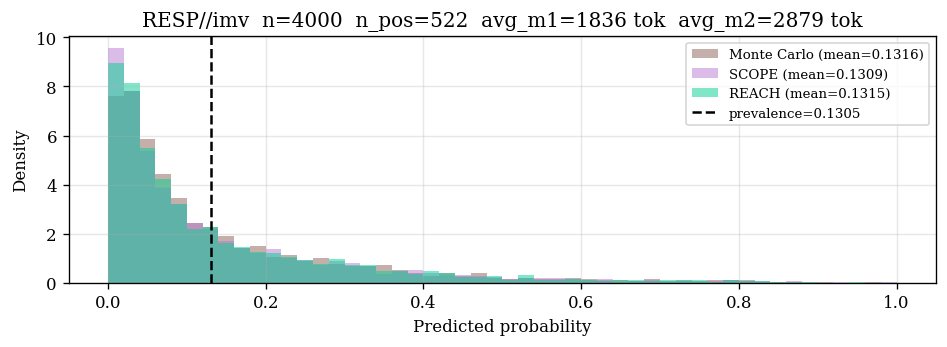

  RESP//imv: n=4000, n_pos=522 (0.131), avg_m1=1836.3 tok, avg_m2=2879.1 tok


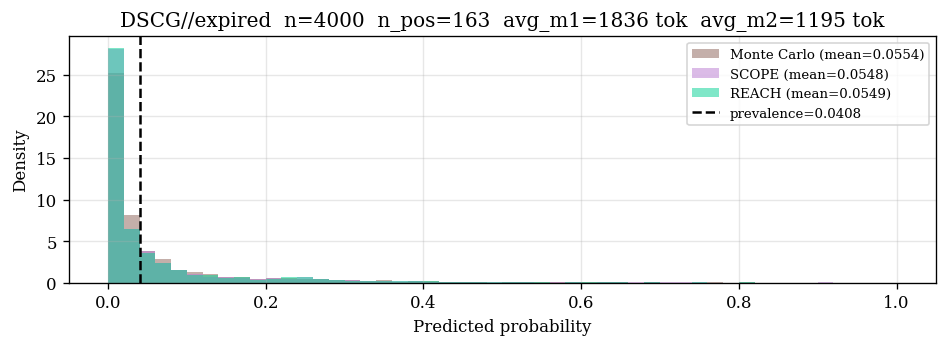

  DSCG//expired: n=4000, n_pos=163 (0.041), avg_m1=1836.3 tok, avg_m2=1194.8 tok


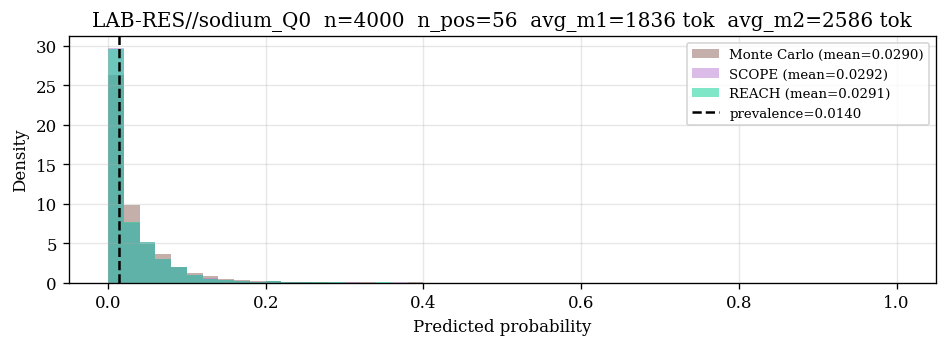

  LAB-RES//sodium_Q0: n=4000, n_pos=56 (0.014), avg_m1=1836.3 tok, avg_m2=2586.0 tok


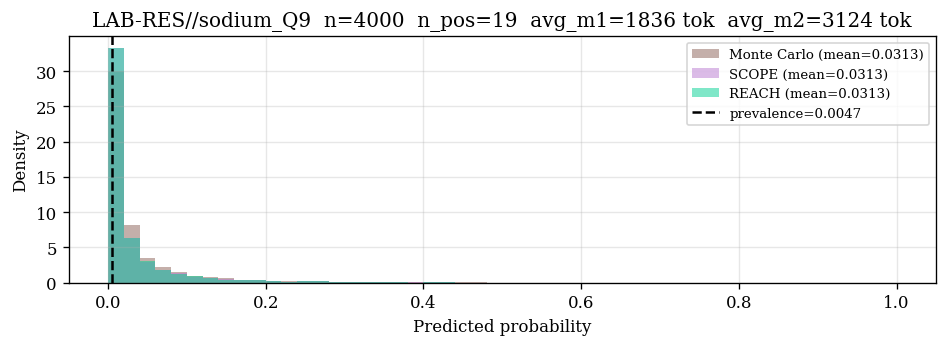

  LAB-RES//sodium_Q9: n=4000, n_pos=19 (0.005), avg_m1=1836.3 tok, avg_m2=3124.0 tok


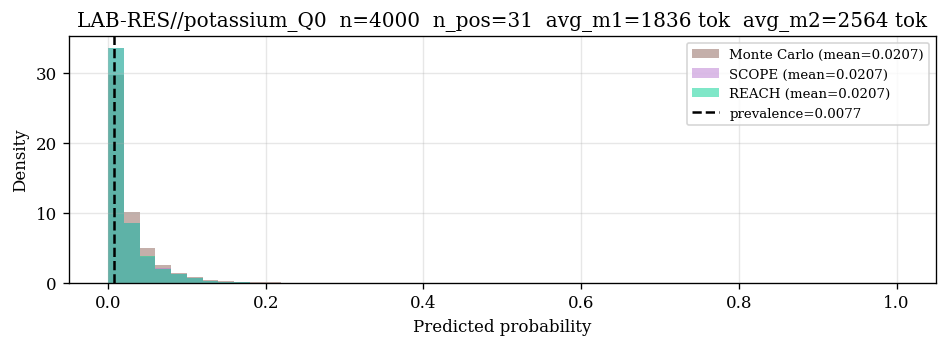

  LAB-RES//potassium_Q0: n=4000, n_pos=31 (0.008), avg_m1=1836.3 tok, avg_m2=2564.0 tok


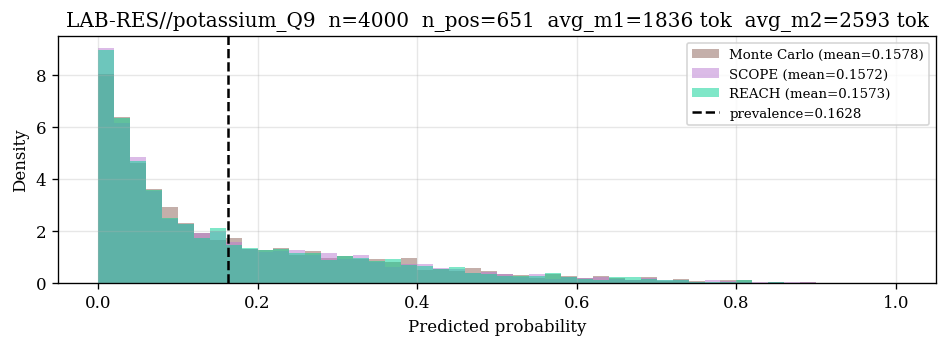

  LAB-RES//potassium_Q9: n=4000, n_pos=651 (0.163), avg_m1=1836.3 tok, avg_m2=2592.6 tok


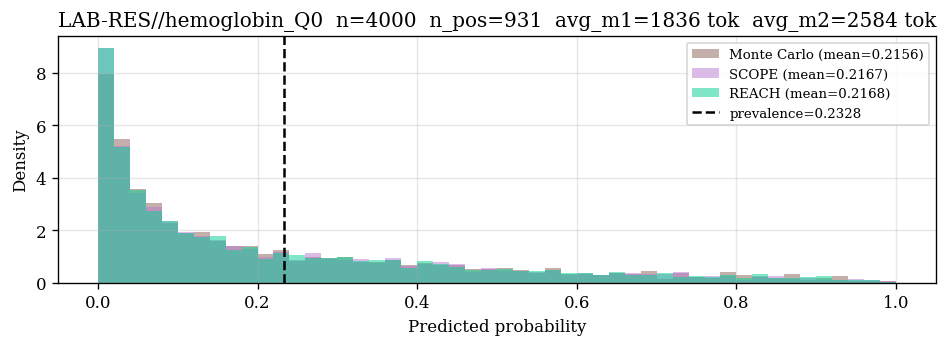

  LAB-RES//hemoglobin_Q0: n=4000, n_pos=931 (0.233), avg_m1=1836.3 tok, avg_m2=2584.5 tok


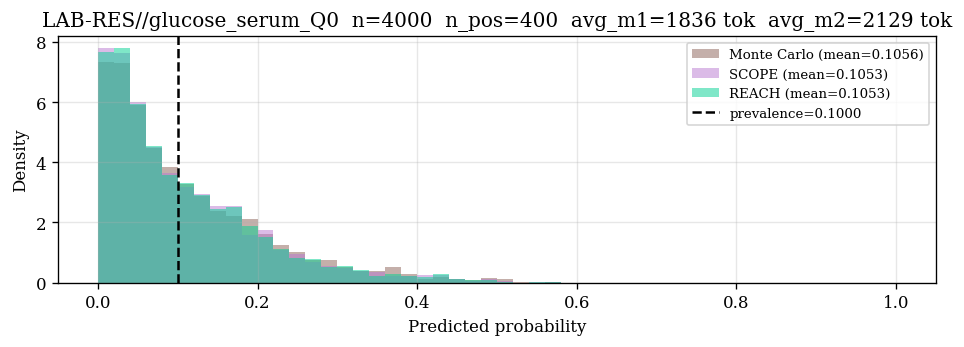

  LAB-RES//glucose_serum_Q0: n=4000, n_pos=400 (0.100), avg_m1=1836.3 tok, avg_m2=2129.5 tok


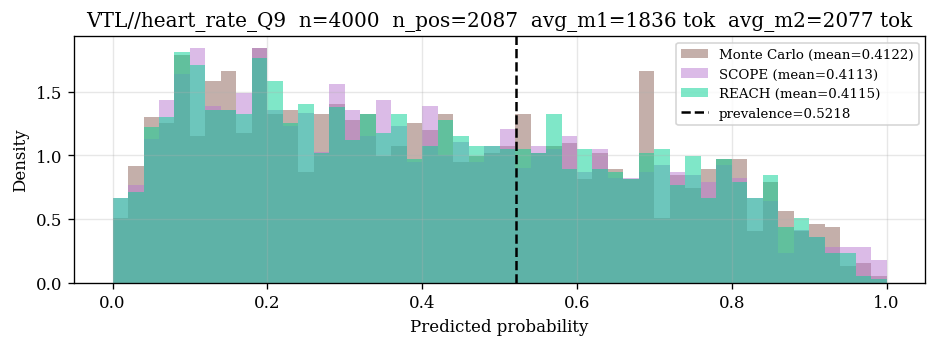

  VTL//heart_rate_Q9: n=4000, n_pos=2087 (0.522), avg_m1=1836.3 tok, avg_m2=2077.4 tok


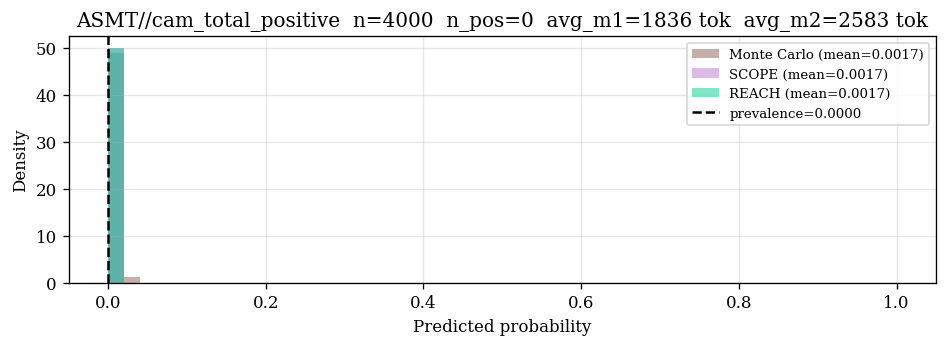

  ASMT//cam_total_positive: n=4000, n_pos=0 (0.000), avg_m1=1836.3 tok, avg_m2=2583.4 tok

Loaded 11 outcomes.


In [4]:
import json

def _load_scores(path):
    """Load scores NPZ, transparently handling v1 (M0_raw) and v2 (M0_flat/offsets)."""
    data = np.load(path)
    out = {k: data[k] for k in data.files}
    is_v2 = "schema_version" in data.files and int(data["schema_version"][0]) >= 2
    if is_v2:
        for _p in ("M0", "M1", "M2"):
            _fl = data.get(f"{_p}_flat")
            _of = data.get(f"{_p}_offsets")
            if _fl is not None and _of is not None:
                _n   = len(_of) - 1
                _ls  = np.diff(_of)
                _mx  = int(_ls.max()) if _n > 0 else 0
                _raw = np.full((_n, max(_mx, 1)), np.nan, dtype=np.float32)
                for _i in range(_n):
                    _L = int(_ls[_i])
                    if _L:
                        _raw[_i, :_L] = _fl[_of[_i]:_of[_i] + _L]
                out[f"{_p}_raw"] = _raw
    return out


run_summary_path = OUTPUT_DIR / "run_summary.json"
if not run_summary_path.exists():
    raise FileNotFoundError(run_summary_path)
with open(run_summary_path) as _f:
    _run_summary = json.load(_f)

_run_subject_ids = _run_summary.get("subject_ids")
if _run_subject_ids is None:
    raise KeyError("run_summary.json has no 'subject_ids' key")

# Build subject_id → run-local patient_idx mapping (shared across all outcomes)
_sid_map = pl.DataFrame({
    "subject_id": _run_subject_ids,
    "patient_idx": list(range(len(_run_subject_ids))),
})

_index_df_full = (
    pl.read_parquet(index_path)
    .drop("patient_idx")
    .filter(pl.col("subject_id").is_in(_run_subject_ids))
    .join(_sid_map, on="subject_id", how="left")
    .sort("patient_idx")
)

_ALL_SAMPLE_SIZES = [1, 2, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

outcome_data = {}
for _name in OUTCOME_NAMES:
    _safe = _name.replace("/", "_").replace(" ", "_")
    _scores_path = OUTPUT_DIR / f"scores_{_safe}.npz"

    _outcome_col = f"{_name}_future"
    if _outcome_col not in _index_df_full.columns:
        print(f"WARNING: '{_outcome_col}' not found in patient_index — skipping {_name}")
        continue

    _y_true = _index_df_full[_outcome_col].to_numpy().astype(bool)

    _sd      = _load_scores(_scores_path)
    _M0      = _sd["M0"]
    _M1      = _sd["M1"]
    _M2      = _sd["M2"]
    _arr_m0  = _sd["M0_raw"]
    _arr_m1  = _sd["M1_raw"]
    _arr_m2  = _sd["M2_raw"]
    _lens_m0 = (~np.isnan(_arr_m0)).sum(axis=1).astype(np.int32)
    _lens_m1 = (~np.isnan(_arr_m1)).sum(axis=1).astype(np.int32)
    _lens_m2 = (~np.isnan(_arr_m2)).sum(axis=1).astype(np.int32)

    assert len(_y_true) == len(_M0), (
        f"{_name}: y_true ({len(_y_true)}) vs scores ({len(_M0)}) length mismatch"
    )

    _avg_m1  = float(_sd["avg_m1_tokens"][0]) if "avg_m1_tokens" in _sd else np.nan
    _avg_m2  = float(_sd["avg_m2_tokens"][0]) if "avg_m2_tokens" in _sd else np.nan
    _n_pts   = len(_y_true)
    _n_pos   = int(_y_true.sum())
    _max_n   = max(int(_lens_m1.max()), int(_lens_m2.max())) if _n_pts > 0 else 10
    _ss      = sorted({s for s in _ALL_SAMPLE_SIZES if s <= _max_n} | {_max_n})

    # Histogram of prediction distributions
    _fig, _ax = plt.subplots(figsize=(8, 3), dpi=120)
    _bins = np.linspace(0, 1, 51)
    for _est, _sc in [("Monte Carlo", _M0), ("SCOPE", _M1), ("REACH", _M2)]:
        _v = _sc[np.isfinite(_sc)]
        _ax.hist(_v, bins=_bins, alpha=0.5, color=COLORS[_est],
                 label=f"{_est} (mean={_v.mean():.4f})", density=True)
    _ax.axvline(_y_true.mean(), color="k", linestyle="--", linewidth=1.5,
                label=f"prevalence={_y_true.mean():.4f}")
    _ax.set_xlabel("Predicted probability")
    _ax.set_ylabel("Density")
    _ax.set_title(
        f"{_name}  n={_n_pts}  n_pos={_n_pos}  "
        f"avg_m1={_avg_m1:.0f} tok  avg_m2={_avg_m2:.0f} tok"
    )
    _ax.legend(fontsize=8)
    _ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    outcome_data[_name] = {
        "y_true":        _y_true,
        "M0": _M0,  "M1": _M1,  "M2": _M2,
        "arr_m0":        _arr_m0,
        "arr_m1":        _arr_m1,
        "arr_m2":        _arr_m2,
        "lens_m0":       _lens_m0,
        "lens_m1":       _lens_m1,
        "lens_m2":       _lens_m2,
        "avg_tokens_m1": _avg_m1,
        "avg_tokens_m2": _avg_m2,
        "n_patients":    _n_pts,
        "n_pos":         _n_pos,
        "prevalence":    float(_y_true.mean()),
        "CAN_COMPUTE_AUC": _n_pos > 0 and _n_pos < _n_pts,
        "SAMPLE_SIZES":  _ss,
        "N_STRAPS":      10,
        "N_BINS":        max(3, min(10, _n_pts // 15)),
        "N_BOOT_CI":     min(2000, max(200, _n_pts * 10)),
    }
    print(
        f"  {_name}: n={_n_pts}, n_pos={_n_pos} ({_y_true.mean():.3f}), "
        f"avg_m1={_avg_m1:.1f} tok, avg_m2={_avg_m2:.1f} tok"
    )

print(f"\nLoaded {len(outcome_data)} outcomes.")

## Bootstrap utilities

In [5]:
Generator: typing.TypeAlias = np.random._generator.Generator


def bootstrap_ci(
    y_true: np.ndarray,
    y_score: np.ndarray,
    *,
    n_samples: int = 10_000,
    alpha: float = 0.05,
    rng: Generator = np.random.default_rng(seed=42),
    objs: tuple = ("roc_auc", "brier"),
    n_jobs: int = -1,
) -> dict:
    """Percentile bootstrap CI for roc_auc and/or brier score."""

    def _one(rng_i):
        warnings.filterwarnings("ignore")
        idx = rng_i.choice(len(y_true), size=len(y_true), replace=True)
        yt, ys = y_true[idx], y_score[idx]
        out = {}
        if "roc_auc" in objs:
            out["roc_auc"] = skl_mets.roc_auc_score(yt, ys)
        if "brier" in objs:
            out["brier"] = skl_mets.brier_score_loss(yt, np.clip(ys, 0, 1))
        return out

    with jl.Parallel(n_jobs=n_jobs) as par:
        scores = par(jl.delayed(_one)(ri) for ri in rng.spawn(n_samples))

    return {
        ob: np.nanquantile([s[ob] for s in scores], q=[alpha / 2, 1 - alpha / 2])
        for ob in objs
    }


def bootstrap_pval(
    y_true: np.ndarray,
    y_score0: np.ndarray,
    y_score1: np.ndarray,
    *,
    n_samples: int = 10_000,
    rng: Generator = np.random.default_rng(seed=42),
    alternative: typing.Literal["one-sided", "two-sided"] = "one-sided",
    objs: tuple = ("roc_auc", "brier"),
    n_jobs: int = -1,
) -> dict:
    """Bootstrap p-value: H0 that score0 and score1 are equally good."""

    def _diffs(rng_i):
        warnings.filterwarnings("ignore")
        idx = rng_i.choice(len(y_true), size=len(y_true), replace=True)
        yt0, ys0 = y_true[idx], y_score0[idx]
        yt1, ys1 = y_true[idx], y_score1[idx]
        d = {}
        if "roc_auc" in objs:
            d["roc_auc"] = skl_mets.roc_auc_score(yt1, ys1) - skl_mets.roc_auc_score(yt0, ys0)
        if "brier" in objs:
            d["brier"] = -(skl_mets.brier_score_loss(yt1, np.clip(ys1, 0, 1)) - skl_mets.brier_score_loss(yt0, np.clip(ys0, 0, 1)))
        return d

    obs_diffs = {}
    if "roc_auc" in objs:
        obs_diffs["roc_auc"] = skl_mets.roc_auc_score(y_true, y_score1) - skl_mets.roc_auc_score(y_true, y_score0)
    if "brier" in objs:
        obs_diffs["brier"] = -(skl_mets.brier_score_loss(y_true, np.clip(y_score1, 0, 1)) - skl_mets.brier_score_loss(y_true, np.clip(y_score0, 0, 1)))

    with jl.Parallel(n_jobs=n_jobs) as par:
        boot_diffs = par(jl.delayed(_diffs)(ri) for ri in rng.spawn(n_samples))

    pvals = {}
    for ob in objs:
        d_obs  = obs_diffs[ob]
        d_boot = np.array([b[ob] for b in boot_diffs])
        if alternative == "one-sided":
            pvals[ob] = float(np.mean(d_boot >= d_obs))
        else:
            pvals[ob] = float(np.mean(np.abs(d_boot) >= np.abs(d_obs)))
    return pvals

In [6]:
BOOT_FRACTION = 0.5   # fraction of patients drawn per strap
N_STRAPS      = 100

def _make_joint_ctx(
    arr_m0, lens_m0,
    arr_m1, lens_m1,
    arr_m2, lens_m2,
    y_true,
):
    """Align all three estimators to their common valid patient set."""
    valid = (lens_m0 > 0) & (lens_m1 > 0) & (lens_m2 > 0)

    def _prep(arr, lens):
        a = arr[valid].astype(np.float64)
        np.nan_to_num(a, copy=False, nan=0.0)
        return a, lens[valid].astype(np.int32)

    return {
        "data":   [_prep(a, l) for a, l in
                   [(arr_m0, lens_m0), (arr_m1, lens_m1), (arr_m2, lens_m2)]],
        "y_true": y_true[valid],
    }


def _subsample_aucs_joint(
    ctx: dict,
    sample_sizes: list[int],
    n_straps: int,
    fraction: float,
    rng: np.random.Generator,
) -> list:
    """
    For each strap:
      1. Draw `fraction` of patients without replacement
      2. Per estimator: random-permute each patient's samples via noise argsort
      3. cumsum along permutation → means at every n in one pass
      4. roc_auc_score at each sample size

    Returns list of ((mc_auc, sc_auc, re_auc), n) — identical format to before.
    """
    y_true   = ctx["y_true"]
    N        = len(y_true)
    n_subset = max(10, int(N * fraction))
    max_n    = max(sample_sizes)
    n_denom  = np.arange(1, max_n + 1, dtype=np.float64)

    auc_list = []
    for _ in range(n_straps):
        idx   = rng.choice(N, size=n_subset, replace=False)
        y_sub = y_true[idx]

        if y_sub.sum() == 0 or (~y_sub).sum() == 0:
            auc_list.extend([((np.nan, np.nan, np.nan), n) for n in sample_sizes])
            continue

        cum_means_list = []
        for arr_full, lens_full in ctx["data"]:
            arr_s   = arr_full[idx]               # [n_subset, max_len]
            lens_s  = lens_full[idx]              # [n_subset]
            max_len = arr_s.shape[1]

            noise = rng.random((n_subset, max_len))
            noise[np.arange(max_len)[None, :] >= lens_s[:, None]] = np.inf
            order = np.argsort(noise, axis=1)[:, :max_n]   # random permutation, [n_subset, max_n]

            # fill tail for patients with fewer than max_n valid samples
            for i in np.where(lens_s < max_n)[0]:
                L = int(lens_s[i])
                order[i, L:] = rng.integers(0, L, size=max_n - L)

            shuffled  = arr_s[np.arange(n_subset)[:, None], order]
            cum_means = np.cumsum(shuffled, axis=1) / n_denom   # [n_subset, max_n]
            cum_means_list.append(cum_means)

        for n in sample_sizes:
            col = n - 1
            try:
                mc = float(skl_mets.roc_auc_score(y_sub, cum_means_list[0][:, col]))
                sc = float(skl_mets.roc_auc_score(y_sub, cum_means_list[1][:, col]))
                re = float(skl_mets.roc_auc_score(y_sub, cum_means_list[2][:, col]))
            except Exception:
                mc = sc = re = np.nan
            auc_list.append(((mc, sc, re), n))

    return auc_list

## Full-sample AUC / Brier with bootstrap CIs

In [7]:
rng_ci = np.random.default_rng(seed=42)

for _name, _od in outcome_data.items():
    print(f"\n=== {_name} ===")
    if not _od["CAN_COMPUTE_AUC"]:
        print(f"  Skipping — n_pos={_od['n_pos']} in {_od['n_patients']} patients.")
        continue

    _y = _od["y_true"]
    print(f"  {'Estimator':<14}  {'AUC':>6}  {'95% CI':>13}  {'Brier':>7}  {'95% CI':>13}")
    print("  " + "-" * 60)
    for _est_name, _scores in [("Monte Carlo", _od["M0"]), ("SCOPE", _od["M1"]), ("REACH", _od["M2"])]:
        _valid = ~np.isnan(_scores)
        if _valid.sum() == 0:
            print(f"  {_est_name:<14}  no valid scores")
            continue
        _scores_clipped = np.clip(_scores[_valid], 0, 1)
        _auc   = skl_mets.roc_auc_score(_y[_valid], _scores[_valid])
        _brier = brier_score_loss(_y[_valid], _scores_clipped)
        _ci    = bootstrap_ci(_y[_valid], _scores_clipped, n_samples=_od["N_BOOT_CI"], rng=rng_ci)
        _alo, _ahi = _ci["roc_auc"]
        _blo, _bhi = _ci["brier"]
        print(
            f"  {_est_name:<14}  {_auc:.4f}  [{_alo:.4f},{_ahi:.4f}]"
            f"  {_brier:.5f}  [{_blo:.5f},{_bhi:.5f}]"
        )

    # Empirical spontaneity: mean over patients of p*(1-p), where p = individual REACH score
    _m2 = _od["M2"]
    _valid_m2 = _m2[~np.isnan(_m2)]
    arr_m2   = _od["arr_m2"]   # [n_patients, max_samples]
    lens_m2  = _od["lens_m2"]  # [n_patients]
    valid_pts = lens_m2 > 0
    per_patient = np.array([
        np.nanmean(arr_m2[i, :lens_m2[i]] * (1 - arr_m2[i, :lens_m2[i]]))
        for i in np.where(valid_pts)[0]
    ])
    _spontaneity = float(np.nanmean(per_patient))

    print(f"  {'Spontaneity':<14}  {_spontaneity:.5f}  (mean p·(1-p) over {len(_valid_m2)} patients, p=REACH)")


=== XFR-IN//icu ===
  Estimator          AUC         95% CI    Brier         95% CI
  ------------------------------------------------------------
  Monte Carlo     0.8989  [0.8807,0.9155]  0.05500  [0.04996,0.06030]
  SCOPE           0.9000  [0.8834,0.9155]  0.05458  [0.04965,0.05950]
  REACH           0.9003  [0.8822,0.9176]  0.05439  [0.04930,0.05943]
  Spontaneity     0.02302  (mean p·(1-p) over 3157 patients, p=REACH)

=== RESP//imv ===
  Estimator          AUC         95% CI    Brier         95% CI
  ------------------------------------------------------------
  Monte Carlo     0.9134  [0.8974,0.9291]  0.04770  [0.04401,0.05149]
  SCOPE           0.9099  [0.8933,0.9265]  0.04766  [0.04399,0.05153]
  REACH           0.9126  [0.8947,0.9280]  0.04750  [0.04382,0.05136]
  Spontaneity     0.03418  (mean p·(1-p) over 3622 patients, p=REACH)

=== DSCG//expired ===
  Estimator          AUC         95% CI    Brier         95% CI
  ---------------------------------------------------------

## AUC vs number of samples (subsampling bootstrap)

In [8]:
rng_sub = np.random.default_rng(seed=0)

for _name, _od in tqdm(outcome_data.items(), desc="Outcomes", unit="outcome"):
    if not _od["CAN_COMPUTE_AUC"]:
        _od["auc_list"] = []
        continue

    _ctx = _make_joint_ctx(
        _od["arr_m0"], _od["lens_m0"],
        _od["arr_m1"], _od["lens_m1"],
        _od["arr_m2"], _od["lens_m2"],
        _od["y_true"],
    )
    _od["auc_list"] = _subsample_aucs_joint(
        _ctx, _od["SAMPLE_SIZES"], N_STRAPS, BOOT_FRACTION, rng_sub
    )

print("Bootstrap complete.")
for _name, _od in outcome_data.items():
    n_sz = len(_od["SAMPLE_SIZES"])
    n_st = len(_od["auc_list"]) // n_sz if n_sz else 0
    print(f"  {_name}: {len(_od['auc_list'])} entries ({n_st} straps × {n_sz} sizes)")


Outcomes: 100%|██████████| 11/11 [01:25<00:00,  7.74s/outcome]

Bootstrap complete.
  XFR-IN//icu: 2300 entries (100 straps × 23 sizes)
  RESP//imv: 2300 entries (100 straps × 23 sizes)
  DSCG//expired: 2300 entries (100 straps × 23 sizes)
  LAB-RES//sodium_Q0: 2300 entries (100 straps × 23 sizes)
  LAB-RES//sodium_Q9: 2300 entries (100 straps × 23 sizes)
  LAB-RES//potassium_Q0: 2300 entries (100 straps × 23 sizes)
  LAB-RES//potassium_Q9: 2300 entries (100 straps × 23 sizes)
  LAB-RES//hemoglobin_Q0: 2300 entries (100 straps × 23 sizes)
  LAB-RES//glucose_serum_Q0: 2300 entries (100 straps × 23 sizes)
  VTL//heart_rate_Q9: 2300 entries (100 straps × 23 sizes)
  ASMT//cam_total_positive: 0 entries (0 straps × 23 sizes)


## AUC vs sample-size plot

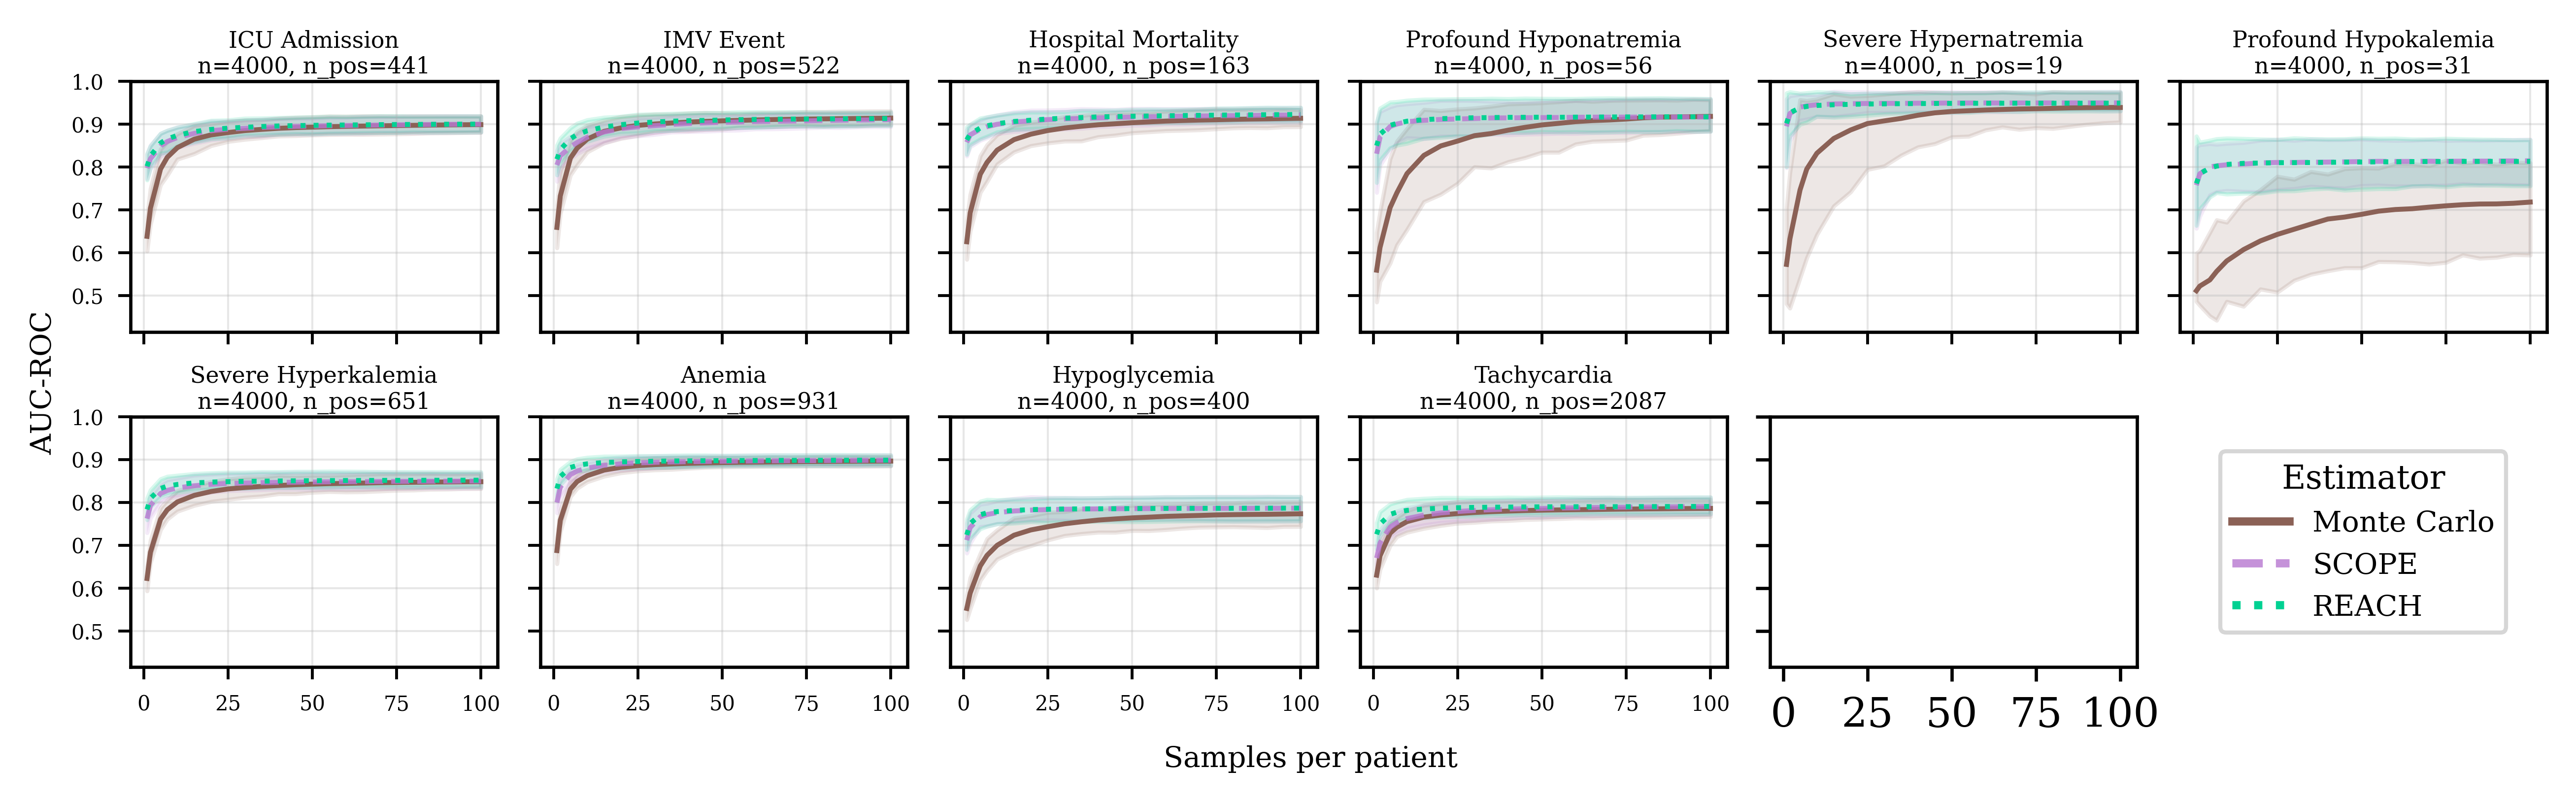

In [9]:
NAME_MAP = {
    "XFR-IN//icu":                   "ICU Admission",
    "RESP//imv":                      "IMV Event",
    "DSCG//expired":                  "Hospital Mortality",
    "LAB-RES//sodium_Q0":             "Profound Hyponatremia",
    "LAB-RES//sodium_Q9":             "Severe Hypernatremia",
    "LAB-RES//potassium_Q0":          "Profound Hypokalemia",
    "LAB-RES//potassium_Q9":          "Severe Hyperkalemia",
    "LAB-RES//hemoglobin_Q0":         "Anemia",
    "LAB-RES//glucose_serum_Q0":      "Hypoglycemia",
    "VTL//heart_rate_Q9":             "Tachycardia",
    "ASMT//cam_total_positive":       "Positive Confusion Test",
}

LINESTYLES = {"Monte Carlo": "-", "SCOPE": "--", "REACH": ":"}

def _display_name(name):
    return NAME_MAP.get(name, name)

def _ci95(by_n, samp_list):
    lo, hi = [], []
    for n in samp_list:
        v = np.array(by_n[n])
        lo.append(np.percentile(v, 2.5))
        hi.append(np.percentile(v, 97.5))
    return np.array(lo), np.array(hi)


items = [(name, od) for name, od in outcome_data.items() if od["auc_list"]]

fig, axes = plt.subplots(2, 6, figsize=(8.5, 2.5), dpi=600,
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

for idx, (name, od) in enumerate(items[:11]):
    ax = axes_flat[idx]
    auc_list  = od["auc_list"]
    samp_list = np.array(sorted(set(item[1] for item in auc_list)))
    mc_by_n   = {n: [item[0][0] for item in auc_list if item[1] == n] for n in samp_list}
    sc_by_n   = {n: [item[0][1] for item in auc_list if item[1] == n] for n in samp_list}
    re_by_n   = {n: [item[0][2] for item in auc_list if item[1] == n] for n in samp_list}

    for est, by_n in [("Monte Carlo", mc_by_n), ("SCOPE", sc_by_n), ("REACH", re_by_n)]:
        mean = np.array([np.mean(by_n[n]) for n in samp_list])
        lo, hi = _ci95(by_n, samp_list)
        c  = COLORS[est]
        ls = LINESTYLES[est]
        ax.plot(samp_list, mean, color=c, linewidth=1.2, linestyle=ls)
        ax.fill_between(samp_list, lo, hi, color=c, alpha=0.15)

    ax.set_title(f"{_display_name(name)}\nn={od['n_patients']}, n_pos={od['n_pos']}", fontsize=5.5, pad=2)
    ax.tick_params(axis="both", labelsize=5, width=0.7, length=3)
    ax.grid(True, alpha=0.3, linewidth=0.5)

axes_flat[0].set_ylim(top=1.0)

fig.text(0.5, -0.02, "Samples per patient", ha="center", fontsize=7)
fig.text(-0.01, 0.5, "AUC-ROC", va="center", rotation="vertical", fontsize=7)

legend_ax = axes_flat[11]
legend_ax.axis("off")
handles = [plt.Line2D([0], [0], color=COLORS[est], linewidth=2,
                      linestyle=LINESTYLES[est], label=est)
           for est in ["Monte Carlo", "SCOPE", "REACH"]]
legend_ax.legend(handles=handles, loc="center", fontsize=7,
                 title="Estimator", title_fontsize=8)

plt.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.3)
plt.show()


In [10]:
import polars as pl

EPSILON = 0.01
pl.Config.set_tbl_rows(-1)
def find_convergence_n(aucs, samp_list, baseline, epsilon):
    within = np.asarray(aucs) >= baseline - epsilon
    for i, n in enumerate(samp_list):
        if np.all(within[i:]):
            return int(n)
    return None

def _ci95(vals):
    clean = np.array([v for v in vals if v is not None], dtype=float)
    if len(clean) == 0:
        return None, None
    return float(np.percentile(clean, 2.5)), float(np.percentile(clean, 97.5))

def _fmt(val, lo, hi, d=1):
    if val is None:
        return "—"
    l = f"{lo:.{d}f}" if lo is not None else "?"
    h = f"{hi:.{d}f}" if hi is not None else "?"
    return f"{val:.{d}f} [{l}, {h}]"

rows = []
all_strap_rsc = []   # [outcome][strap] → ratio or None
all_strap_rre = []

for name, od in outcome_data.items():
    auc_list = od["auc_list"]
    if not auc_list:
        continue

    samp_list    = np.array(od["SAMPLE_SIZES"])
    n_sizes      = len(samp_list)
    n_straps     = len(auc_list) // n_sizes
    baseline_idx = int(np.argmax(samp_list == 100) if 100 in samp_list else len(samp_list) - 1)

    strap_mc, strap_sc, strap_re = [], [], []
    strap_rsc, strap_rre         = [], []

    for s in range(n_straps):
        sl   = auc_list[s * n_sizes : (s + 1) * n_sizes]
        mc_s = np.array([e[0][0] for e in sl])
        sc_s = np.array([e[0][1] for e in sl])
        re_s = np.array([e[0][2] for e in sl])
        b    = float(mc_s[baseline_idx])

        nmc = find_convergence_n(mc_s, samp_list, b, EPSILON)
        nsc = find_convergence_n(sc_s, samp_list, b, EPSILON)
        nre = find_convergence_n(re_s, samp_list, b, EPSILON)
        strap_mc.append(nmc);  strap_sc.append(nsc);  strap_re.append(nre)
        strap_rsc.append(nmc / nsc if (nmc and nsc) else None)
        strap_rre.append(nmc / nre if (nmc and nre) else None)

    all_strap_rsc.append(strap_rsc)
    all_strap_rre.append(strap_rre)

    mc_mean = np.array([np.mean([e[0][0] for e in auc_list if e[1] == n]) for n in samp_list])
    sc_mean = np.array([np.mean([e[0][1] for e in auc_list if e[1] == n]) for n in samp_list])
    re_mean = np.array([np.mean([e[0][2] for e in auc_list if e[1] == n]) for n in samp_list])
    b_mean  = float(mc_mean[baseline_idx])

    nmc = find_convergence_n(mc_mean, samp_list, b_mean, EPSILON)
    nsc = find_convergence_n(sc_mean, samp_list, b_mean, EPSILON)
    nre = find_convergence_n(re_mean, samp_list, b_mean, EPSILON)

    mc_lo,  mc_hi  = _ci95(strap_mc)
    sc_lo,  sc_hi  = _ci95(strap_sc)
    re_lo,  re_hi  = _ci95(strap_re)
    rsc_lo, rsc_hi = _ci95(strap_rsc)
    rre_lo, rre_hi = _ci95(strap_rre)

    rows.append({
        "outcome":    NAME_MAP.get(name, name),
        "n_MC":       nmc,  "n_MC_lo":    mc_lo,  "n_MC_hi":    mc_hi,
        "n_SCOPE":    nsc,  "n_SCOPE_lo": sc_lo,  "n_SCOPE_hi": sc_hi,
        "n_REACH":    nre,  "n_REACH_lo": re_lo,  "n_REACH_hi": re_hi,
        "r_SCOPE":    nmc / nsc if (nmc and nsc) else None,
        "r_SCOPE_lo": rsc_lo, "r_SCOPE_hi": rsc_hi,
        "r_REACH":    nmc / nre if (nmc and nre) else None,
        "r_REACH_lo": rre_lo, "r_REACH_hi": rre_hi,
    })

# ── per-strap mean/median across outcomes → CI on summary ────────────────
n_straps_common = min(len(s) for s in all_strap_rsc)

strap_mean_rsc, strap_median_rsc = [], []
strap_mean_rre, strap_median_rre = [], []

for s in range(n_straps_common):
    vsc = [all_strap_rsc[o][s] for o in range(len(all_strap_rsc)) if all_strap_rsc[o][s] is not None]
    vre = [all_strap_rre[o][s] for o in range(len(all_strap_rre)) if all_strap_rre[o][s] is not None]
    strap_mean_rsc.append(float(np.mean(vsc))   if vsc else None)
    strap_median_rsc.append(float(np.median(vsc)) if vsc else None)
    strap_mean_rre.append(float(np.mean(vre))   if vre else None)
    strap_median_rre.append(float(np.median(vre)) if vre else None)

# ── display ──────────────────────────────────────────────────────────────
display_df = pl.DataFrame({
    "Outcome":  [r["outcome"]  for r in rows],
    "n_MC":     [_fmt(r["n_MC"],    r["n_MC_lo"],    r["n_MC_hi"],    d=0) for r in rows],
    "n_SCOPE":  [_fmt(r["n_SCOPE"], r["n_SCOPE_lo"], r["n_SCOPE_hi"], d=0) for r in rows],
    "n_REACH":  [_fmt(r["n_REACH"], r["n_REACH_lo"], r["n_REACH_hi"], d=0) for r in rows],
    "MC/SCOPE": [_fmt(r["r_SCOPE"], r["r_SCOPE_lo"], r["r_SCOPE_hi"], d=2) for r in rows],
    "MC/REACH": [_fmt(r["r_REACH"], r["r_REACH_lo"], r["r_REACH_hi"], d=2) for r in rows],
})
print(f"ε = {EPSILON}  (auc ≥ baseline − ε)\n")
print(display_df)

point_rsc = np.nanmean([r["r_SCOPE"] for r in rows if r["r_SCOPE"] is not None])
point_rre = np.nanmean([r["r_REACH"] for r in rows if r["r_REACH"] is not None])
point_med_rsc = np.nanmedian([r["r_SCOPE"] for r in rows if r["r_SCOPE"] is not None])
point_med_rre = np.nanmedian([r["r_REACH"] for r in rows if r["r_REACH"] is not None])

summary = pl.DataFrame({
    "ratio":  ["MC/SCOPE", "MC/REACH"],
    "mean":   [
        _fmt(point_rsc, *_ci95(strap_mean_rsc),   d=3),
        _fmt(point_rre, *_ci95(strap_mean_rre),   d=3),
    ],
    "median": [
        _fmt(point_med_rsc, *_ci95(strap_median_rsc), d=3),
        _fmt(point_med_rre, *_ci95(strap_median_rre), d=3),
    ],
})
print("\nSummary across outcomes:")
print(summary)


ε = 0.01  (auc ≥ baseline − ε)

shape: (10, 6)
┌───────────────┬──────────────┬─────────────┬─────────────┬──────────────┬────────────────────────┐
│ Outcome       ┆ n_MC         ┆ n_SCOPE     ┆ n_REACH     ┆ MC/SCOPE     ┆ MC/REACH               │
│ ---           ┆ ---          ┆ ---         ┆ ---         ┆ ---          ┆ ---                    │
│ str           ┆ str          ┆ str         ┆ str         ┆ str          ┆ str                    │
╞═══════════════╪══════════════╪═════════════╪═════════════╪══════════════╪════════════════════════╡
│ ICU Admission ┆ 40 [20, 65]  ┆ 30 [15, 50] ┆ 25 [15, 40] ┆ 1.33 [0.64,  ┆ 1.60 [0.60, 3.33]      │
│               ┆              ┆             ┆             ┆ 2.23]        ┆                        │
│ IMV Event     ┆ 40 [20, 63]  ┆ 50 [27, 93] ┆ 30 [17, 60] ┆ 0.80 [0.34,  ┆ 1.33 [0.50, 2.75]      │
│               ┆              ┆             ┆             ┆ 1.57]        ┆                        │
│ Hospital      ┆ 55 [30, 85]  ┆ 15 [5, 45] 

Single token cost graph

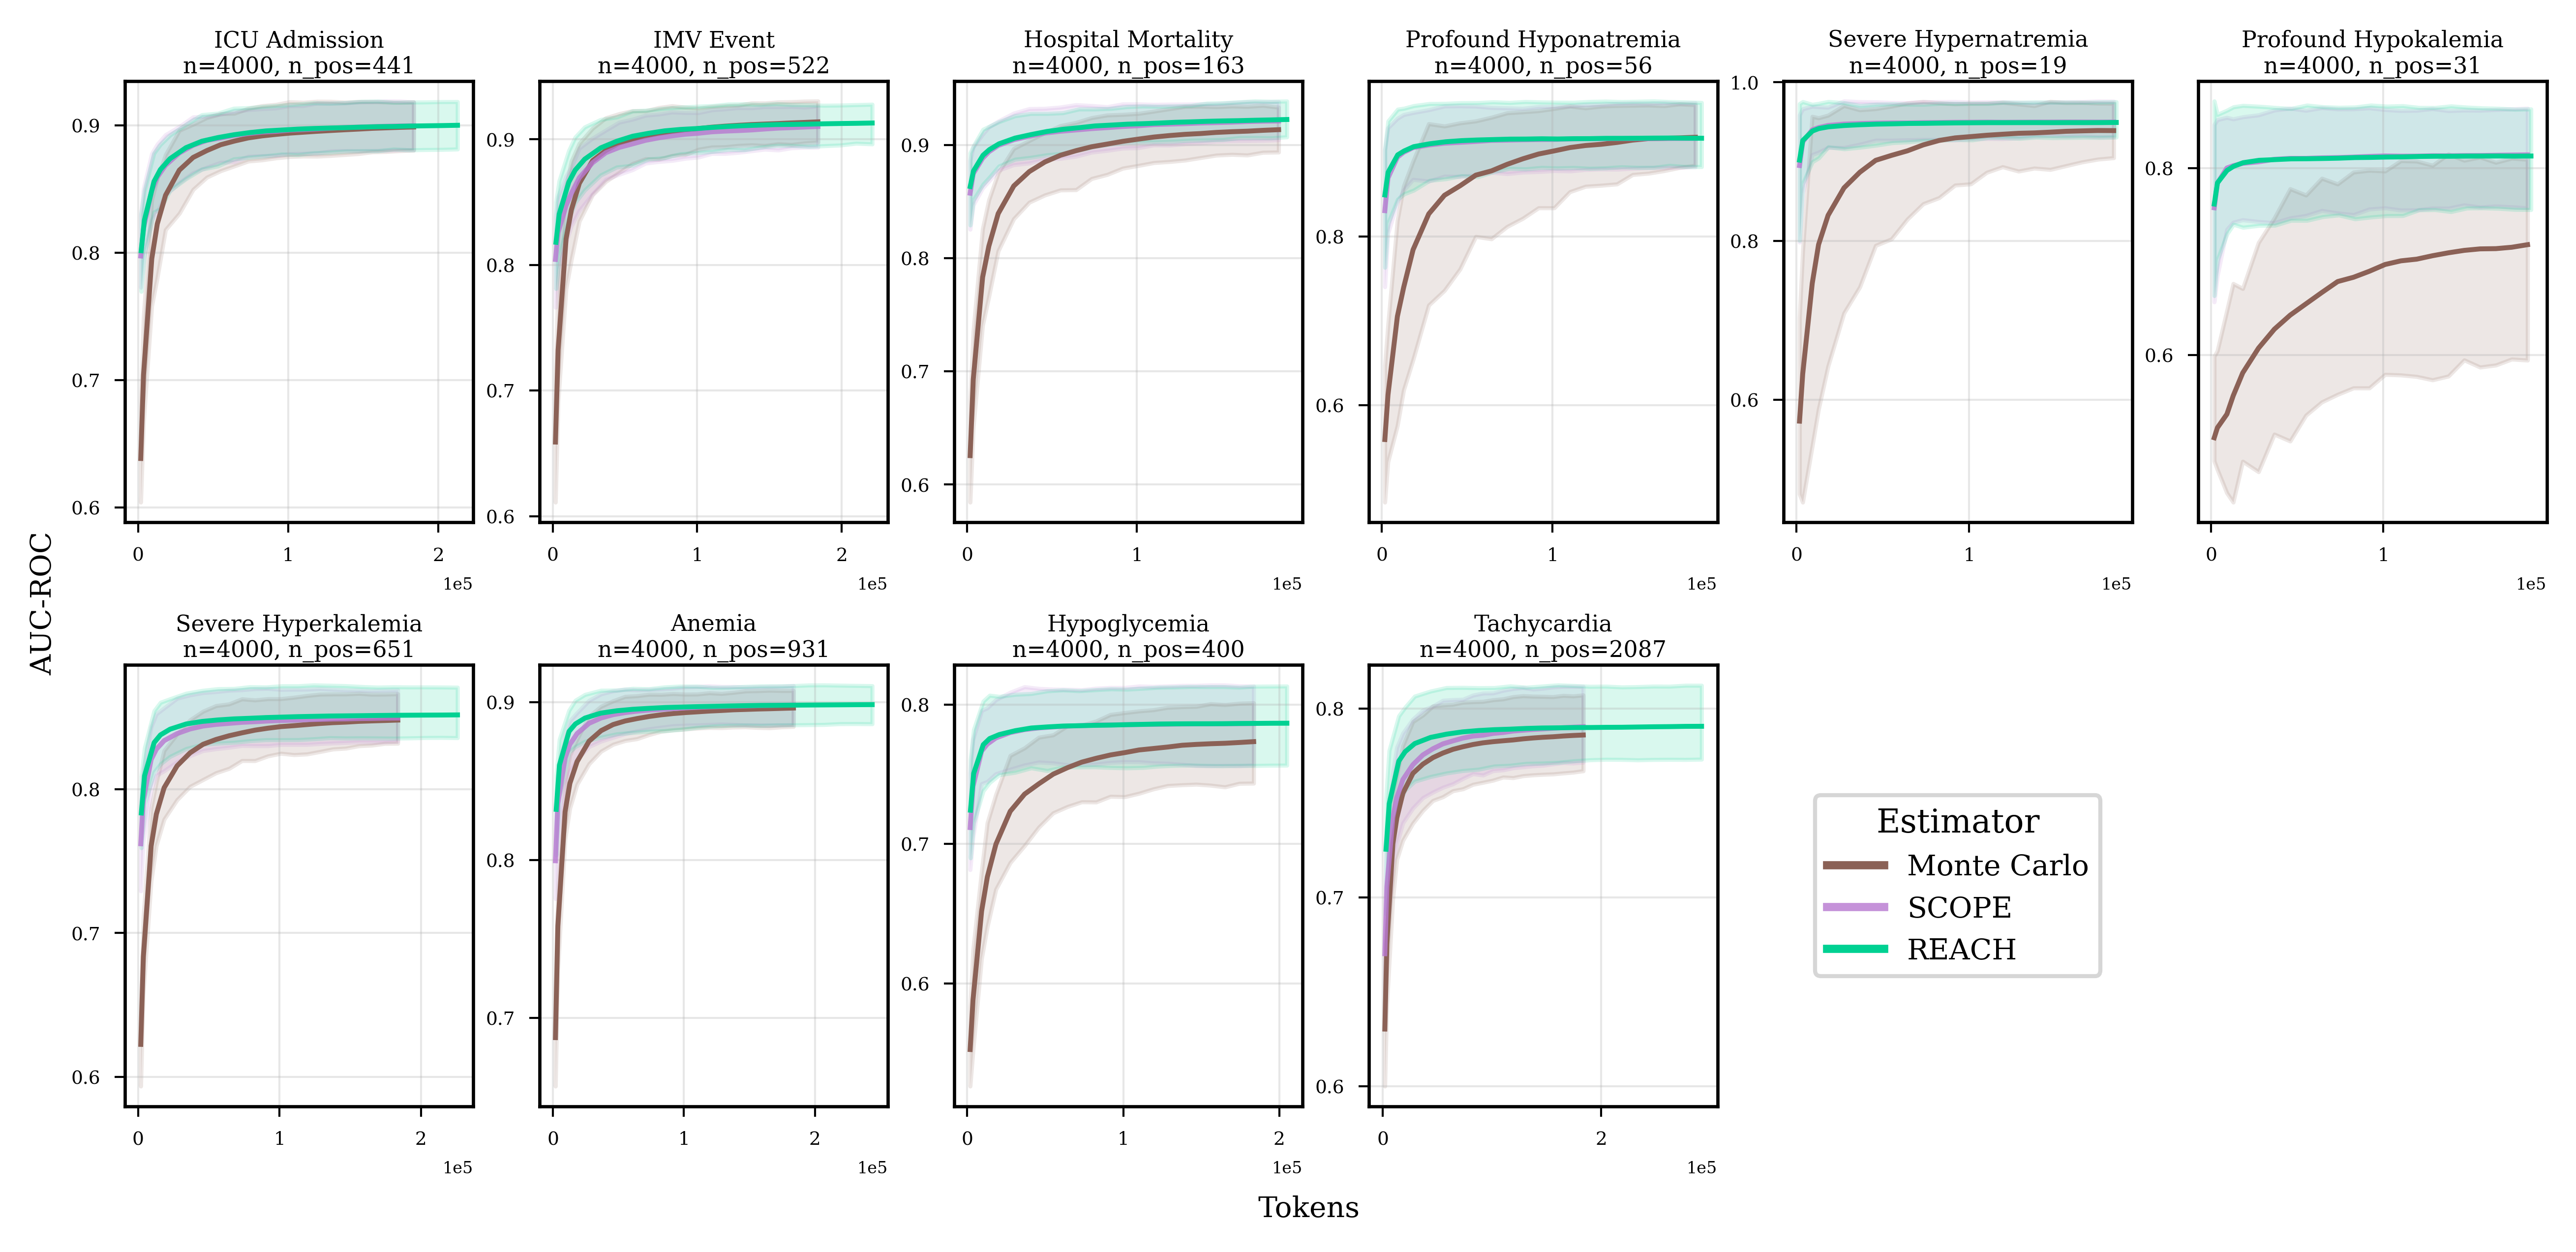

In [17]:
items = [(name, od) for name, od in outcome_data.items() if od["auc_list"]]

fig, axes = plt.subplots(2, 6, figsize=(8.5, 4), dpi=600)
axes_flat = axes.flatten()

for idx, (name, od) in enumerate(items[:11]):
    ax        = axes_flat[idx]
    auc_list  = od["auc_list"]
    samp_list = np.array(od["SAMPLE_SIZES"])
    avg_m1    = od["avg_tokens_m1"]
    avg_m2    = od["avg_tokens_m2"]
    prev      = od["prevalence"]

    tok_mc = samp_list * avg_m1
    tok_sc = samp_list * avg_m1
    tok_re = samp_list * (avg_m1 + prev * avg_m2)

    mc_by_n = {n: [e[0][0] for e in auc_list if e[1] == n] for n in samp_list}
    sc_by_n = {n: [e[0][1] for e in auc_list if e[1] == n] for n in samp_list}
    re_by_n = {n: [e[0][2] for e in auc_list if e[1] == n] for n in samp_list}

    for est, by_n, tok_x in [
        ("Monte Carlo", mc_by_n, tok_mc),
        ("SCOPE",       sc_by_n, tok_sc),
        ("REACH",       re_by_n, tok_re),
    ]:
        mean = np.array([np.mean(by_n[n]) for n in samp_list])
        lo   = np.array([np.percentile(by_n[n], 2.5)  for n in samp_list])
        hi   = np.array([np.percentile(by_n[n], 97.5) for n in samp_list])
        c    = COLORS[est]
        ax.plot(tok_x, mean, color=c, linewidth=1.2)
        ax.fill_between(tok_x, lo, hi, color=c, alpha=0.15)

    ax.set_title(f"{_display_name(name)}\nn={od['n_patients']}, n_pos={od['n_pos']}", fontsize=5.5, pad=2)
    ax.tick_params(axis="both", labelsize=4.5, width=0.5, length=2.5)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax.xaxis.get_offset_text().set_fontsize(4)
    ax.locator_params(axis="x", nbins=3)
    ax.locator_params(axis="y", nbins=4)
    ax.grid(True, alpha=0.3, linewidth=0.5)

fig.text(0.5, -0.02, "Tokens", ha="center", fontsize=7)
fig.text(-0.01, 0.5, "AUC-ROC", va="center", rotation="vertical", fontsize=7)

legend_ax = axes_flat[10]
legend_ax.axis("off")
axes_flat[11].axis("off")
handles = [plt.Line2D([0], [0], color=COLORS[est], linewidth=2, label=est)
           for est in ["Monte Carlo", "SCOPE", "REACH"]]
legend_ax.legend(handles=handles, loc="center", fontsize=7, title="Estimator", title_fontsize=8)
plt.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.3)
plt.show()


Single Outcome Cost Efficiency Table

In [12]:
def find_convergence_tok(aucs, tok_list, baseline, epsilon):
    within = np.asarray(aucs) >= baseline - epsilon
    for i, t in enumerate(tok_list):
        if np.all(within[i:]):
            return float(t)
    return None

def _fmt_tok(val, lo, hi):
    if val is None:
        return "—"
    f = lambda v: "?" if v is None else f"{v:,.0f}"
    return f"{val:,.0f} [{f(lo)}, {f(hi)}]"

rows_tok = []
all_strap_rsc_tok = []
all_strap_rre_tok = []

for name, od in outcome_data.items():
    auc_list = od["auc_list"]
    if not auc_list:
        continue

    samp_list    = np.array(od["SAMPLE_SIZES"])
    n_sizes      = len(samp_list)
    n_straps     = len(auc_list) // n_sizes
    baseline_idx = int(np.argmax(samp_list == 100) if 100 in samp_list else len(samp_list) - 1)

    avg_m1 = od["avg_tokens_m1"]
    avg_m2 = od["avg_tokens_m2"]
    prev   = np.nanmean(od["M0"])

    tok_mc = samp_list * avg_m1
    tok_sc = samp_list * avg_m1
    tok_re = samp_list * (avg_m1 + prev * avg_m2)

    strap_tmc, strap_tsc, strap_tre = [], [], []
    strap_rsc, strap_rre             = [], []

    for s in range(n_straps):
        sl   = auc_list[s * n_sizes : (s + 1) * n_sizes]
        mc_s = np.array([e[0][0] for e in sl])
        sc_s = np.array([e[0][1] for e in sl])
        re_s = np.array([e[0][2] for e in sl])
        b    = float(mc_s[baseline_idx])

        tmc = find_convergence_tok(mc_s, tok_mc, b, EPSILON)
        tsc = find_convergence_tok(sc_s, tok_sc, b, EPSILON)
        tre = find_convergence_tok(re_s, tok_re, b, EPSILON)
        strap_tmc.append(tmc); strap_tsc.append(tsc); strap_tre.append(tre)
        strap_rsc.append(tmc / tsc if (tmc and tsc) else None)
        strap_rre.append(tmc / tre if (tmc and tre) else None)

    all_strap_rsc_tok.append(strap_rsc)
    all_strap_rre_tok.append(strap_rre)

    mc_mean = np.array([np.mean([e[0][0] for e in auc_list if e[1] == n]) for n in samp_list])
    sc_mean = np.array([np.mean([e[0][1] for e in auc_list if e[1] == n]) for n in samp_list])
    re_mean = np.array([np.mean([e[0][2] for e in auc_list if e[1] == n]) for n in samp_list])
    b_mean  = float(mc_mean[baseline_idx])

    tmc = find_convergence_tok(mc_mean, tok_mc, b_mean, EPSILON)
    tsc = find_convergence_tok(sc_mean, tok_sc, b_mean, EPSILON)
    tre = find_convergence_tok(re_mean, tok_re, b_mean, EPSILON)

    tmc_lo, tmc_hi = _ci95(strap_tmc)
    tsc_lo, tsc_hi = _ci95(strap_tsc)
    tre_lo, tre_hi = _ci95(strap_tre)
    rsc_lo, rsc_hi = _ci95(strap_rsc)
    rre_lo, rre_hi = _ci95(strap_rre)

    rows_tok.append({
        "outcome":    NAME_MAP.get(name, name),
        "T_MC":       tmc,  "T_MC_lo":    tmc_lo,  "T_MC_hi":    tmc_hi,
        "T_SCOPE":    tsc,  "T_SCOPE_lo": tsc_lo,  "T_SCOPE_hi": tsc_hi,
        "T_REACH":    tre,  "T_REACH_lo": tre_lo,  "T_REACH_hi": tre_hi,
        "r_SCOPE":    tmc / tsc if (tmc and tsc) else None,
        "r_SCOPE_lo": rsc_lo, "r_SCOPE_hi": rsc_hi,
        "r_REACH":    tmc / tre if (tmc and tre) else None,
        "r_REACH_lo": rre_lo, "r_REACH_hi": rre_hi,
    })

n_straps_common = min(len(s) for s in all_strap_rsc_tok)
strap_mean_rsc_tok, strap_median_rsc_tok = [], []
strap_mean_rre_tok, strap_median_rre_tok = [], []

for s in range(n_straps_common):
    vsc = [all_strap_rsc_tok[o][s] for o in range(len(all_strap_rsc_tok)) if all_strap_rsc_tok[o][s] is not None]
    vre = [all_strap_rre_tok[o][s] for o in range(len(all_strap_rre_tok)) if all_strap_rre_tok[o][s] is not None]
    strap_mean_rsc_tok.append(float(np.mean(vsc))     if vsc else None)
    strap_median_rsc_tok.append(float(np.median(vsc)) if vsc else None)
    strap_mean_rre_tok.append(float(np.mean(vre))     if vre else None)
    strap_median_rre_tok.append(float(np.median(vre)) if vre else None)

pl.Config.set_tbl_rows(-1)
display_df = pl.DataFrame({
    "Outcome":  [r["outcome"]  for r in rows_tok],
    "T_MC":     [_fmt_tok(r["T_MC"],    r["T_MC_lo"],    r["T_MC_hi"])    for r in rows_tok],
    "T_SCOPE":  [_fmt_tok(r["T_SCOPE"], r["T_SCOPE_lo"], r["T_SCOPE_hi"]) for r in rows_tok],
    "T_REACH":  [_fmt_tok(r["T_REACH"], r["T_REACH_lo"], r["T_REACH_hi"]) for r in rows_tok],
    "MC/SCOPE": [_fmt(r["r_SCOPE"], r["r_SCOPE_lo"], r["r_SCOPE_hi"], d=2) for r in rows_tok],
    "MC/REACH": [_fmt(r["r_REACH"], r["r_REACH_lo"], r["r_REACH_hi"], d=2) for r in rows_tok],
})
print(f"ε = {EPSILON}  (token x-axis, REACH cost = M1 + prevalence × M2)\n")
print(display_df)

point_rsc = np.nanmean([r["r_SCOPE"]   for r in rows_tok if r["r_SCOPE"] is not None])
point_rre = np.nanmean([r["r_REACH"]   for r in rows_tok if r["r_REACH"] is not None])
point_med_rsc = np.nanmedian([r["r_SCOPE"] for r in rows_tok if r["r_SCOPE"] is not None])
point_med_rre = np.nanmedian([r["r_REACH"] for r in rows_tok if r["r_REACH"] is not None])

summary = pl.DataFrame({
    "ratio":  ["MC/SCOPE", "MC/REACH"],
    "mean":   [_fmt(point_rsc,     *_ci95(strap_mean_rsc_tok),   d=3),
               _fmt(point_rre,     *_ci95(strap_mean_rre_tok),   d=3)],
    "median": [_fmt(point_med_rsc, *_ci95(strap_median_rsc_tok), d=3),
               _fmt(point_med_rre, *_ci95(strap_median_rre_tok), d=3)],
})
print("\nSummary across outcomes:")
print(summary)


ε = 0.01  (token x-axis, REACH cost = M1 + prevalence × M2)

shape: (10, 6)
┌─────────────────┬──────────┬─────────────────┬─────────────────┬────────────────┬────────────────┐
│ Outcome         ┆ T_MC     ┆ T_SCOPE         ┆ T_REACH         ┆ MC/SCOPE       ┆ MC/REACH       │
│ ---             ┆ ---      ┆ ---             ┆ ---             ┆ ---            ┆ ---            │
│ str             ┆ str      ┆ str             ┆ str             ┆ str            ┆ str            │
╞═════════════════╪══════════╪═════════════════╪═════════════════╪════════════════╪════════════════╡
│ ICU Admission   ┆ 73,451   ┆ 55,088 [27,544, ┆ 52,669 [31,601, ┆ 1.33 [0.64,    ┆ 1.39 [0.52,    │
│                 ┆ [36,725, ┆ 91,813]         ┆ 84,270]         ┆ 2.23]          ┆ 2.91]          │
│                 ┆ 119,357] ┆                 ┆                 ┆                ┆                │
│ IMV Event       ┆ 73,451   ┆ 91,813 [50,038, ┆ 66,452 [38,487, ┆ 0.80 [0.34,    ┆ 1.11 [0.41,    │
│              

## Calibration curves

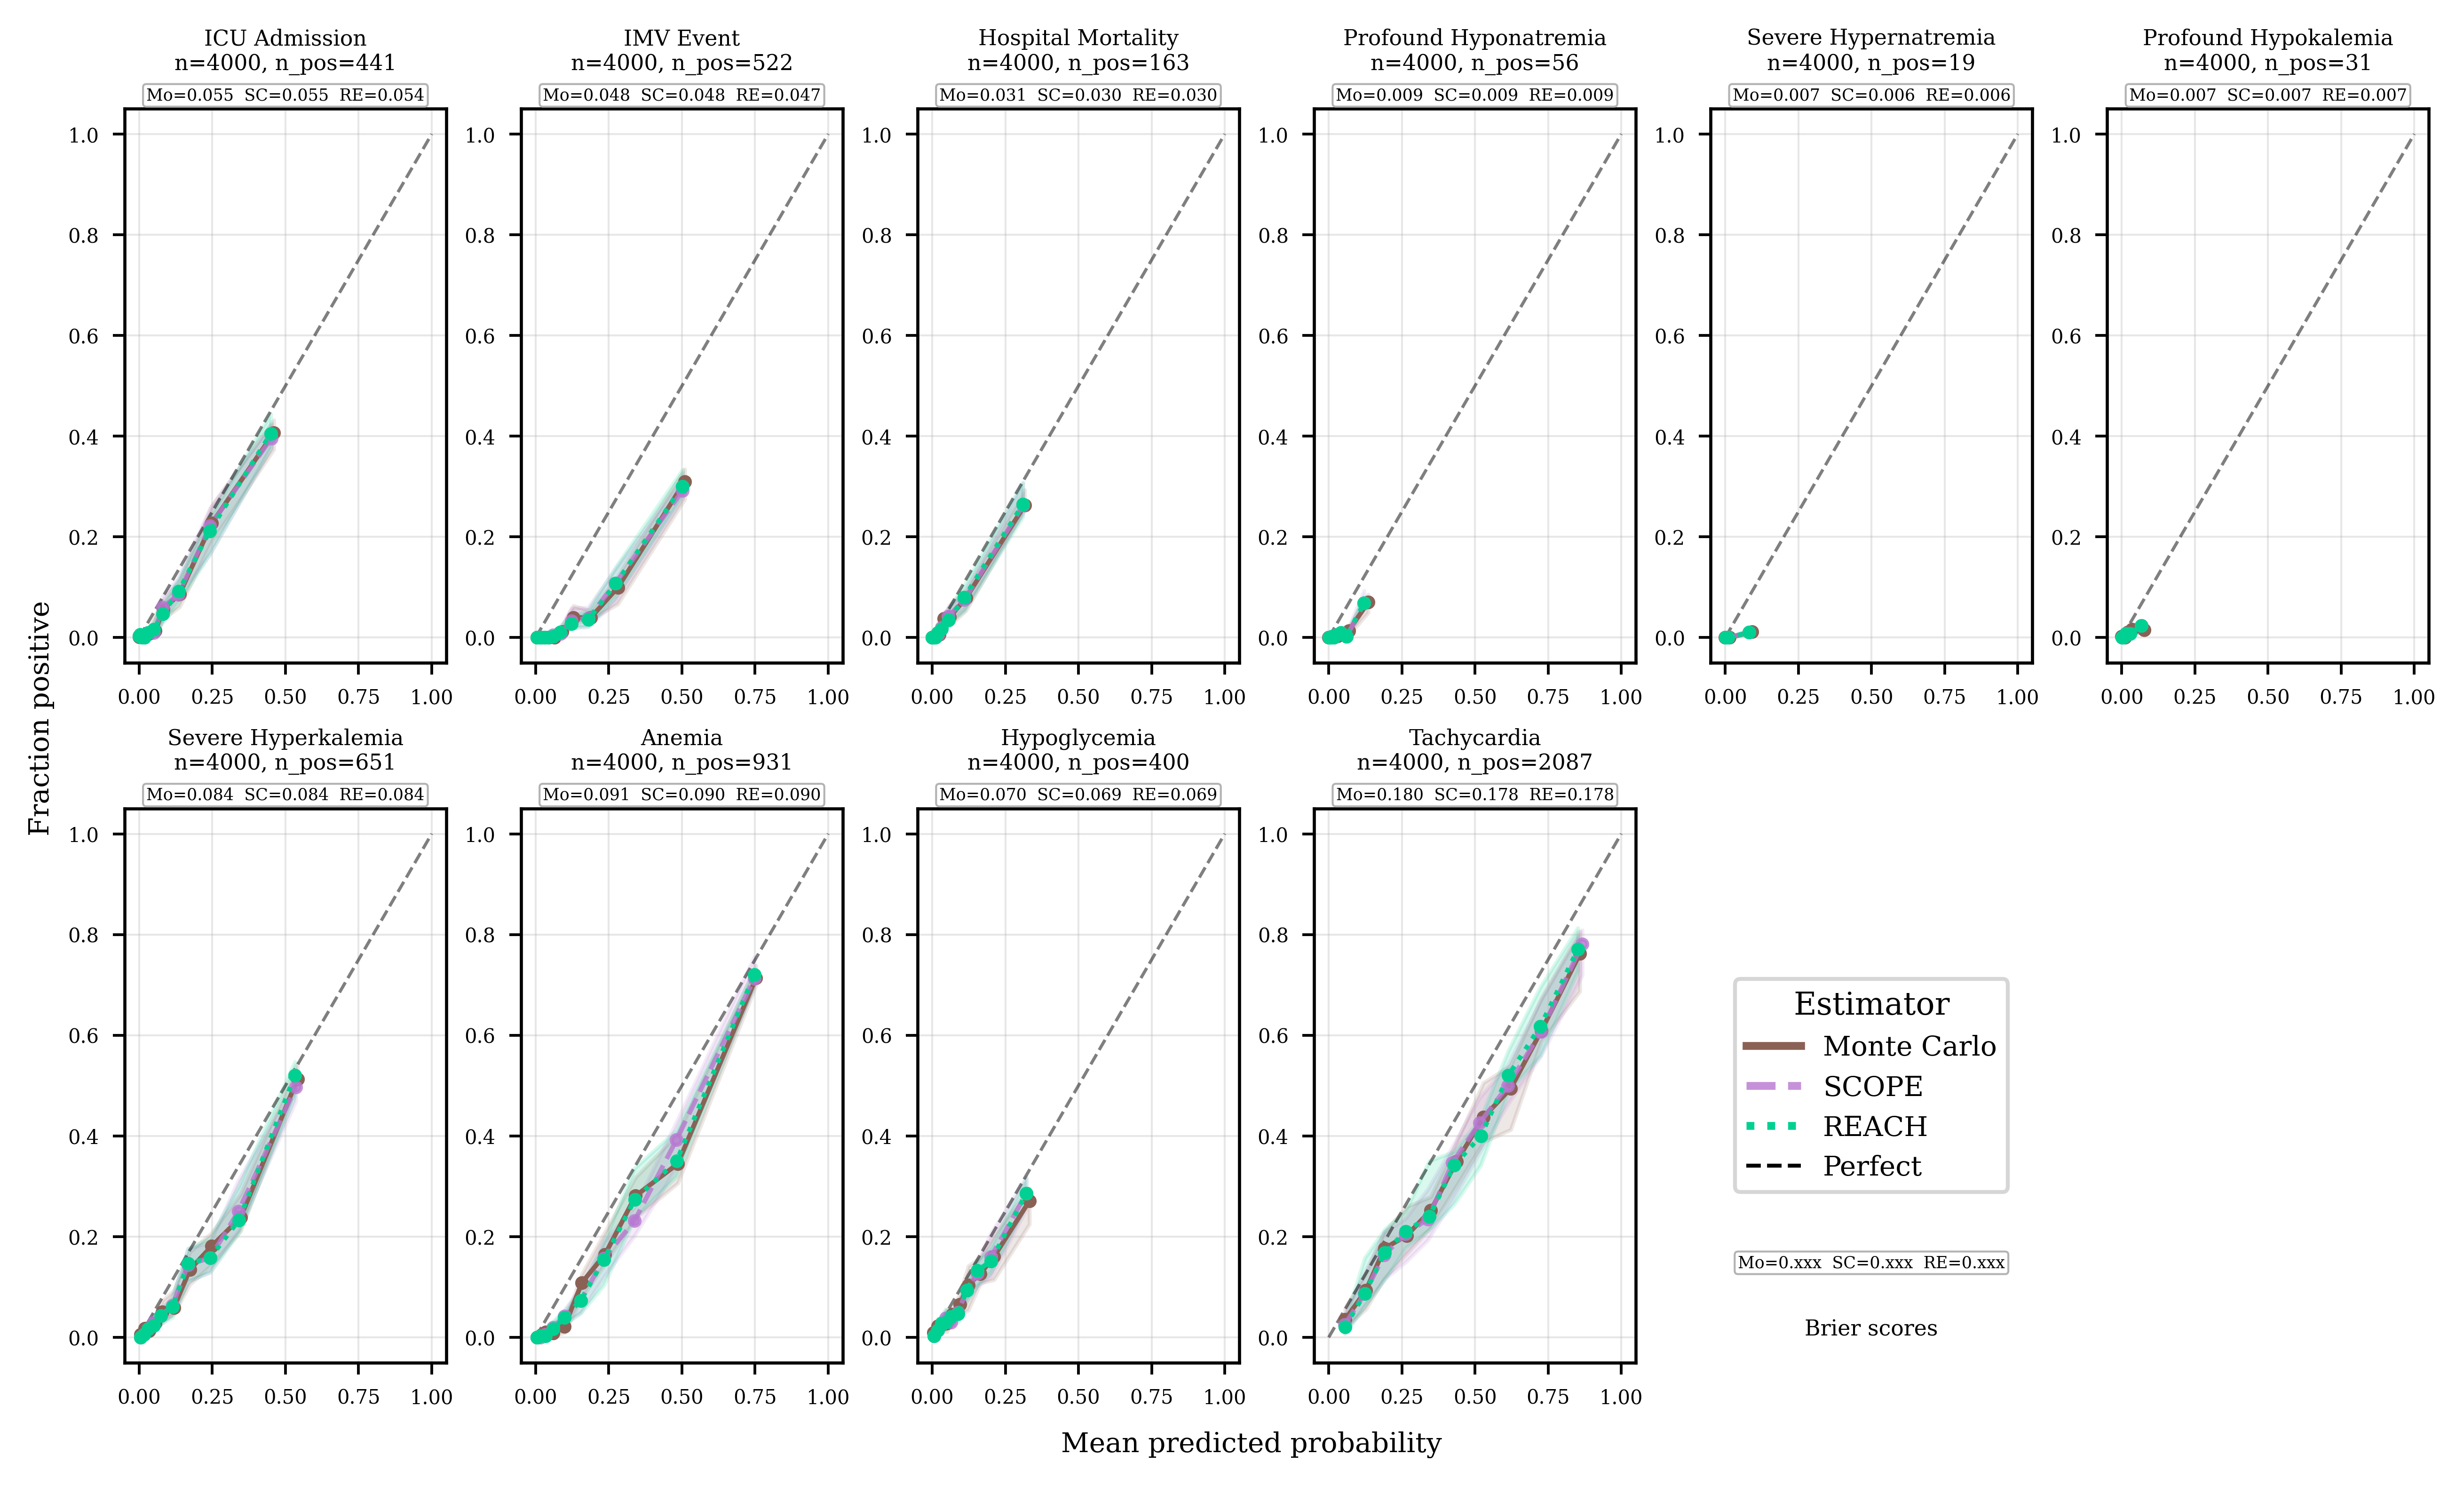

In [18]:
from sklearn.calibration import calibration_curve as _sk_cal_curve

LINESTYLES = {"Monte Carlo": "-", "SCOPE": "--", "REACH": ":"}
N_BOOT_CAL = 20
rng_cal    = np.random.default_rng(seed=7)

items_cal = [(name, od) for name, od in outcome_data.items() if od["CAN_COMPUTE_AUC"]]

fig, axes = plt.subplots(2, 6, figsize=(8.5, 5), dpi=600)
axes_flat = axes.flatten()

for idx, (_name, _od) in enumerate(items_cal[:10]):
    ax = axes_flat[idx]
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)

    _y     = _od["y_true"]
    _M0, _M1, _M2 = _od["M0"], _od["M1"], _od["M2"]
    _n_pts = _od["n_patients"]
    _n_pos = _od["n_pos"]
    _N_BINS = max(3, min(_od["N_BINS"], _n_pos // 5))

    _brier_scores = {}
    for _est, _scores in [("Monte Carlo", _M0), ("SCOPE", _M1), ("REACH", _M2)]:
        _valid = np.isfinite(_scores)
        if _valid.sum() < _N_BINS * 2:
            continue
        _preds = np.clip(_scores[_valid], 0, 1)
        _tgts  = _y[_valid].astype(float)
        _c     = COLORS[_est]
        _ls    = LINESTYLES[_est]
        _n     = len(_preds)

        _fp_full, _mp_full = _sk_cal_curve(_tgts, _preds, n_bins=_N_BINS, strategy="quantile")
        _bs = brier_score_loss(_tgts, _preds)
        _brier_scores[_est] = _bs

        _boot_fp = []
        for _rng_i in rng_cal.spawn(N_BOOT_CAL):
            _idx = _rng_i.integers(0, _n, size=_n)
            try:
                _fp_b, _mp_b = _sk_cal_curve(
                    _tgts[_idx], _preds[_idx], n_bins=_N_BINS, strategy="quantile"
                )
                if len(_mp_b) > 1:
                    _boot_fp.append(
                        np.interp(_mp_full, _mp_b, _fp_b, left=np.nan, right=np.nan)
                    )
            except Exception:
                pass

        if _boot_fp:
            _bc = np.array(_boot_fp)
            ax.fill_between(
                _mp_full,
                np.nanpercentile(_bc, 2.5,  axis=0),
                np.nanpercentile(_bc, 97.5, axis=0),
                color=_c, alpha=0.15,
            )

        ax.plot(_mp_full, _fp_full, color=_c, linestyle=_ls,
                marker="o", markersize=2.5, linewidth=1.2)

    _brier_label = "  ".join(
        f"{est[:2]}={_brier_scores[est]:.3f}"
        for est in ["Monte Carlo", "SCOPE", "REACH"]
        if est in _brier_scores
    )
    ax.text(0.5, 1.01, _brier_label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=4.2,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor="0.7", linewidth=0.5))

    ax.set_title(f"{_display_name(_name)}\nn={_n_pts}, n_pos={_n_pos}", fontsize=5.5, pad=10)
    ax.tick_params(axis="both", labelsize=5, width=0.7, length=3)
    ax.grid(True, alpha=0.3, linewidth=0.5)

legend_ax = axes_flat[10]
legend_ax.axis("off")
axes_flat[11].axis("off")
handles = [plt.Line2D([0], [0], color=COLORS[est], linewidth=2,
                      linestyle=LINESTYLES[est], label=est)
           for est in ["Monte Carlo", "SCOPE", "REACH"]]
handles.append(plt.Line2D([0], [0], color="k", linewidth=1, linestyle="--", label="Perfect"))
legend_ax.legend(handles=handles, loc="center", fontsize=7,
                 title="Estimator", title_fontsize=8)
legend_ax.text(0.5, 0.18, "Mo=0.xxx  SC=0.xxx  RE=0.xxx",
               transform=legend_ax.transAxes, ha="center", va="center", fontsize=4.2,
               bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                         edgecolor="0.7", linewidth=0.5))
legend_ax.text(0.5, 0.06, "Brier scores", transform=legend_ax.transAxes,
               ha="center", va="center", fontsize=5.5)


fig.text(0.5, -0.02, "Mean predicted probability", ha="center", fontsize=7)
fig.text(-0.01, 0.5, "Fraction positive", va="center", rotation="vertical", fontsize=7)
plt.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.3)
plt.show()


Prevalence and Spontaneity Fit Curve

C:\Users\lukea\AppData\Local\Temp\ipykernel_11936\2410542043.py:10: RuntimeWarning: Mean of empty slice
  per_pt = np.nanmean(p1mp, axis=1)


MC / SCOPE  multivariate R²=0.639
  log(efficiency) = -0.971·log(prev) + 0.946·log(spont) + 0.718
MC / REACH  multivariate R²=0.579
  log(efficiency) = -0.880·log(prev) + 1.053·log(spont) + 1.037


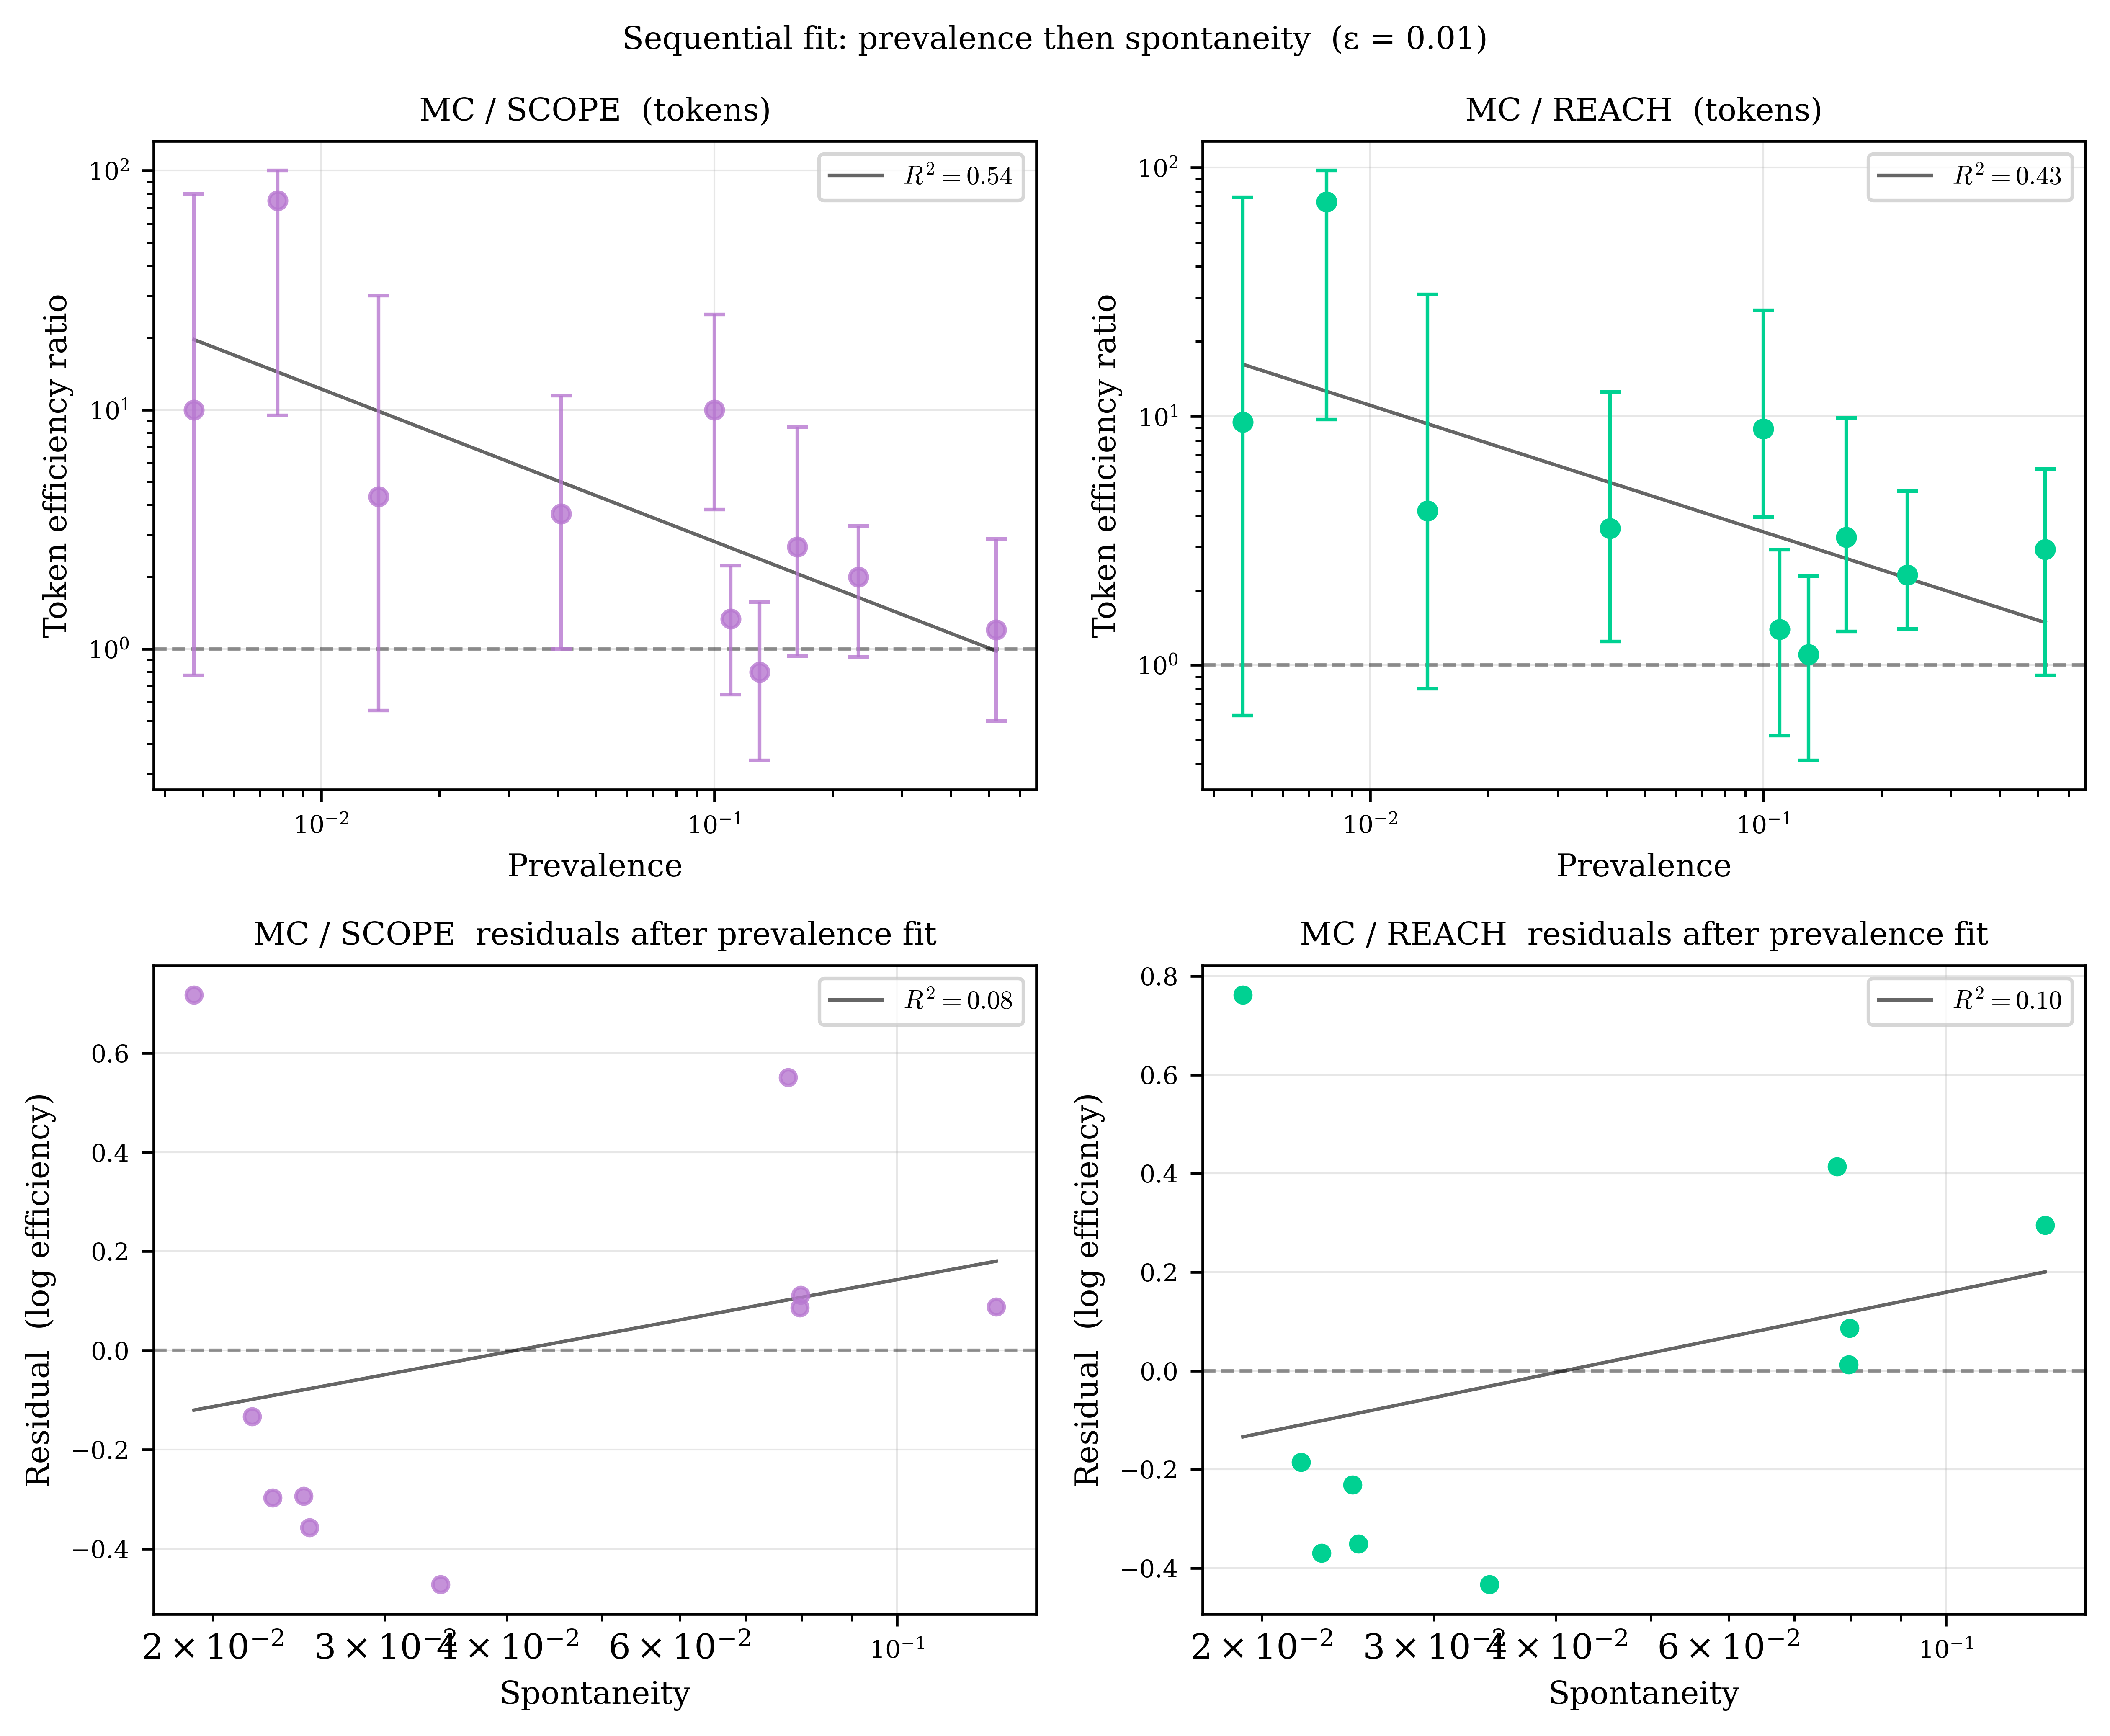

In [14]:
from numpy.linalg import lstsq

prev_list  = [od["prevalence"] for od in outcome_data.values() if od["auc_list"]]

spont_list = []
for od in outcome_data.values():
    if not od["auc_list"]:
        continue
    p1mp   = od["arr_m2"] * (1 - od["arr_m2"])
    per_pt = np.nanmean(p1mp, axis=1)
    spont_list.append(float(np.nanmean(per_pt[od["lens_m2"] > 0])))

lx_prev  = np.log10(prev_list)
lx_spont = np.log10(spont_list)
X_joint  = np.column_stack([lx_prev, lx_spont, np.ones_like(lx_prev)])

fig, axes = plt.subplots(2, 2, figsize=(8.5, 7), dpi=600)

for col, (rk, lok, hik, color, label) in enumerate([
    ("r_SCOPE", "r_SCOPE_lo", "r_SCOPE_hi", COLORS["SCOPE"], "MC / SCOPE"),
    ("r_REACH", "r_REACH_lo", "r_REACH_hi", COLORS["REACH"], "MC / REACH"),
]):
    ys  = np.array([r[rk]  for r in rows_tok], dtype=float)
    elo = np.array([r[rk] - r[lok] if (r[rk] and r[lok]) else 0 for r in rows_tok])
    ehi = np.array([r[hik] - r[rk] if (r[rk] and r[hik]) else 0 for r in rows_tok])
    ly  = np.log10(ys)

    # Multivariate fit (for printing)
    coeffs, *_ = lstsq(X_joint, ly, rcond=None)
    a_mv, b_mv, c_mv = coeffs
    y_hat_mv = X_joint @ coeffs
    r2_mv = 1 - np.sum((ly - y_hat_mv) ** 2) / np.sum((ly - ly.mean()) ** 2)
    print(f"{label}  multivariate R²={r2_mv:.3f}")
    print(f"  log(efficiency) = {a_mv:.3f}·log(prev) + {b_mv:.3f}·log(spont) + {c_mv:.3f}")

    # Step 1: log(y) ~ a*log(prev) + c
    X1       = np.column_stack([lx_prev, np.ones_like(lx_prev)])
    (m1, b1), *_ = lstsq(X1, ly, rcond=None)
    resid    = ly - (m1 * lx_prev + b1)
    ss_tot   = np.sum((ly - ly.mean()) ** 2)
    r2_prev  = 1 - np.sum(resid ** 2) / ss_tot

    # Step 2: residuals ~ b*log(spont) + d
    X2       = np.column_stack([lx_spont, np.ones_like(lx_spont)])
    (m2, b2), *_ = lstsq(X2, resid, rcond=None)
    resid2   = resid - (m2 * lx_spont + b2)
    ss_resid = np.sum((resid - resid.mean()) ** 2)
    r2_spont = 1 - np.sum(resid2 ** 2) / ss_resid

    # Top: prevalence vs efficiency
    ax = axes[0, col]
    xs = np.array(prev_list)
    ax.errorbar(xs, ys, yerr=[elo, ehi],
                fmt="o", color=color, capsize=3, markersize=5, linewidth=1, zorder=3)
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1, alpha=0.4)
    x_fit = np.logspace(np.log10(xs.min()), np.log10(xs.max()), 100)
    ax.plot(x_fit, 10 ** (m1 * np.log10(x_fit) + b1),
            color="k", linewidth=1, alpha=0.6, label=f"$R^2={r2_prev:.2f}$")
    ax.set_xscale("log");  ax.set_yscale("log")
    ax.set_xlabel("Prevalence", fontsize=9)
    ax.set_ylabel("Token efficiency ratio", fontsize=9)
    ax.set_title(f"{label}  (tokens)", fontsize=9)
    ax.legend(fontsize=7.5);  ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    # Bottom: spontaneity vs residuals from step 1
    ax = axes[1, col]
    xs = np.array(spont_list)
    ax.scatter(xs, resid, color=color, s=20, zorder=3)
    ax.axhline(0.0, color="k", linestyle="--", linewidth=1, alpha=0.4)
    x_fit = np.logspace(np.log10(xs.min()), np.log10(xs.max()), 100)
    ax.plot(x_fit, m2 * np.log10(x_fit) + b2,
            color="k", linewidth=1, alpha=0.6, label=f"$R^2={r2_spont:.2f}$")
    ax.set_xscale("log")
    ax.set_xlabel("Spontaneity", fontsize=9)
    ax.set_ylabel("Residual  (log efficiency)", fontsize=9)
    ax.set_title(f"{label}  residuals after prevalence fit", fontsize=9)
    ax.legend(fontsize=7.5);  ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

plt.suptitle(f"Sequential fit: prevalence then spontaneity  (ε = {EPSILON})", fontsize=9)
plt.tight_layout()
plt.show()


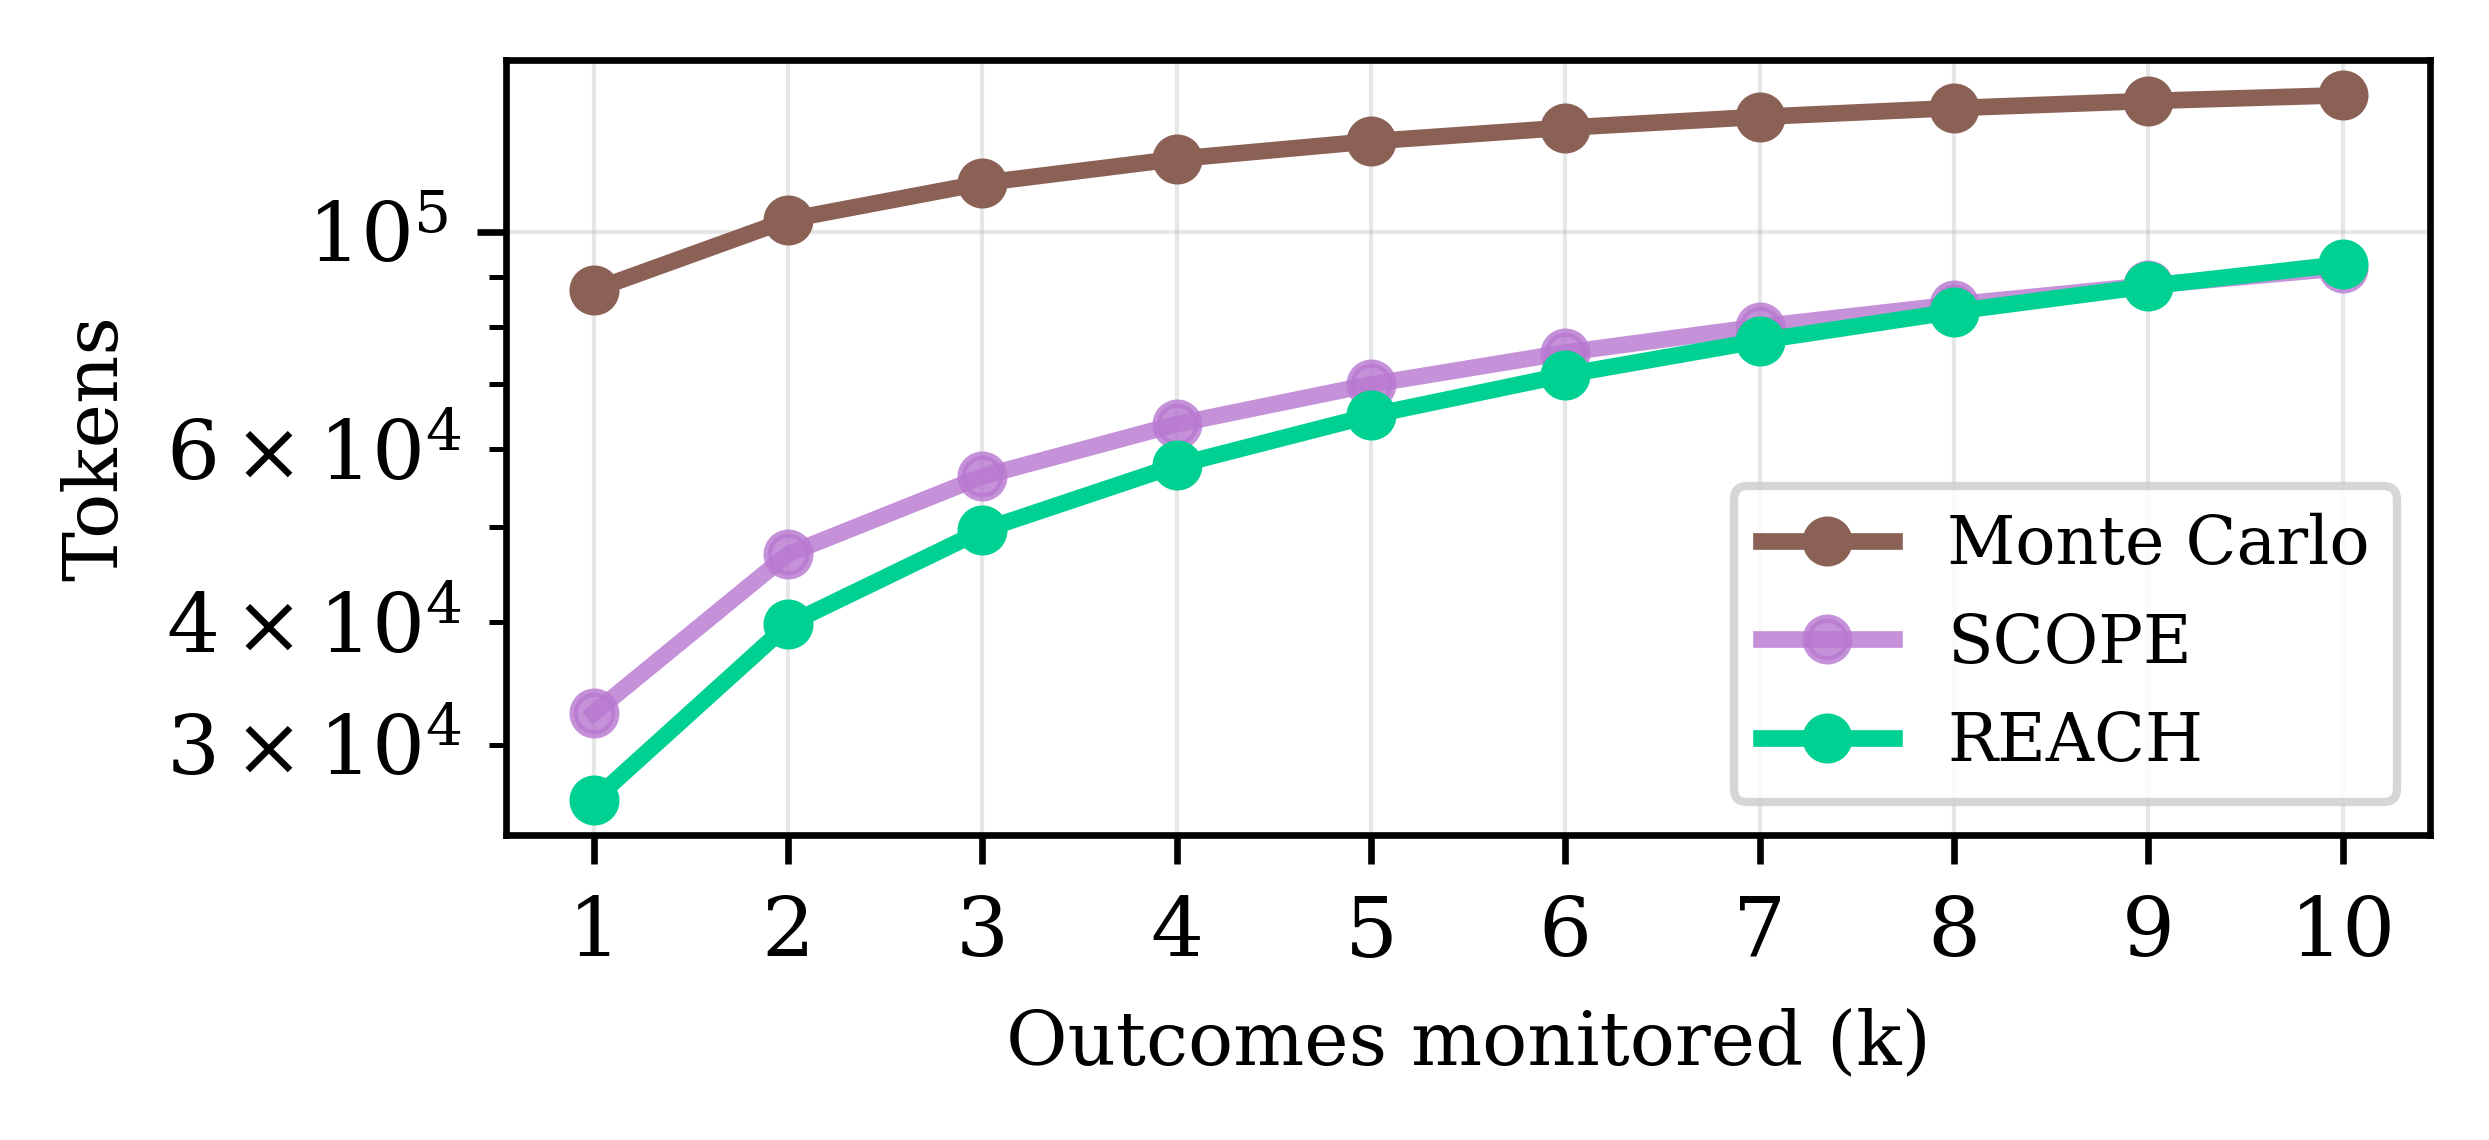

In [15]:
from itertools import combinations

outcome_stats = []
for name, od in outcome_data.items():
    if not od["auc_list"]:
        continue
    samp_list    = np.array(od["SAMPLE_SIZES"])
    baseline_idx = int(np.argmax(samp_list == 100) if 100 in samp_list else len(samp_list) - 1)
    fallback     = int(samp_list[-1])

    mc_mean = np.array([np.mean([e[0][0] for e in od["auc_list"] if e[1] == n]) for n in samp_list])
    sc_mean = np.array([np.mean([e[0][1] for e in od["auc_list"] if e[1] == n]) for n in samp_list])
    re_mean = np.array([np.mean([e[0][2] for e in od["auc_list"] if e[1] == n]) for n in samp_list])
    b_mean  = float(mc_mean[baseline_idx])

    outcome_stats.append(dict(
        nmc    = find_convergence_n(mc_mean, samp_list, b_mean, EPSILON) or fallback,
        nsc    = find_convergence_n(sc_mean, samp_list, b_mean, EPSILON) or fallback,
        nre    = find_convergence_n(re_mean, samp_list, b_mean, EPSILON) or fallback,
        rate   = np.nanmean(od["M0"]),
        avg_m2 = od["avg_tokens_m2"],
    ))

avg_m1_shared = np.mean([od["avg_tokens_m1"] for od in outcome_data.values() if od["auc_list"]])
n_outcomes    = len(outcome_stats)

def _costs(subset):
    stats = [outcome_stats[i] for i in subset]
    mc = max(s["nmc"] for s in stats) * avg_m1_shared
    sc = max(s["nsc"] for s in stats) * avg_m1_shared
    re = (max(s["nre"] for s in stats) * avg_m1_shared
          + sum(s["nre"] * s["rate"] * s["avg_m2"] for s in stats))
    return mc, sc, re

k_arr = np.arange(1, n_outcomes + 1)
mc_means, sc_means, re_means = [], [], []

for k in range(1, n_outcomes + 1):
    mc_vals, sc_vals, re_vals = zip(*[_costs(sub) for sub in combinations(range(n_outcomes), k)])
    mc_means.append(np.mean(mc_vals))
    sc_means.append(np.mean(sc_vals))
    re_means.append(np.mean(re_vals))

fig, ax = plt.subplots(figsize=(4.25, 2), dpi=600)
ax.plot(k_arr, mc_means, color=COLORS["Monte Carlo"], marker="o", markersize=5, linewidth=2, label="Monte Carlo")
ax.plot(k_arr, sc_means, color=COLORS["SCOPE"],       marker="o", markersize=5, linewidth=2, label="SCOPE")
ax.plot(k_arr, re_means, color=COLORS["REACH"],       marker="o", markersize=5, linewidth=2, label="REACH")

ax.set_xticks(k_arr)
ax.set_xlabel("Outcomes monitored (k)", fontsize=9)
ax.set_ylabel("Tokens", fontsize=9)

ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()
